In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer, RobustScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error, classification_report

In [3]:
df = pd.read_csv('polder_data.csv')
df.head()

,timestamp,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,Pump1,Pump2,Pump3,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,pintu,pump_on,status_banjir
0,2025-06-09 00:00:00,0.466032,2.389919,1.819317,on,on,off,0.634561,6.569780,12.875024,0.0,0.0,0.0,1.0,0.0
1,2025-06-09 00:02:27,0.470409,2.398388,1.836405,on,on,off,0.629908,6.559635,12.874414,0.0,0.0,0.0,1.0,0.0
2,2025-06-09 00:07:27,0.479342,2.415673,1.871278,on,on,off,0.620411,6.538929,12.873169,0.0,0.0,0.0,1.0,0.0
3,2025-06-09 00:12:27,0.488275,2.432957,1.906150,on,on,off,0.610914,6.518223,12.871923,0.0,0.0,0.0,1.0,0.0
4,2025-06-09 00:17:27,0.497208,2.450241,1.941023,on,on,off,0.601418,6.497517,12.870678,0.0,0.0,0.0,1.0,0.0


In [4]:
df_copy = df.copy()
df_copy.head()


,timestamp,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,Pump1,Pump2,Pump3,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,pintu,pump_on,status_banjir
0,2025-06-09 00:00:00,0.466032,2.389919,1.819317,on,on,off,0.634561,6.569780,12.875024,0.0,0.0,0.0,1.0,0.0
1,2025-06-09 00:02:27,0.470409,2.398388,1.836405,on,on,off,0.629908,6.559635,12.874414,0.0,0.0,0.0,1.0,0.0
2,2025-06-09 00:07:27,0.479342,2.415673,1.871278,on,on,off,0.620411,6.538929,12.873169,0.0,0.0,0.0,1.0,0.0
3,2025-06-09 00:12:27,0.488275,2.432957,1.906150,on,on,off,0.610914,6.518223,12.871923,0.0,0.0,0.0,1.0,0.0
4,2025-06-09 00:17:27,0.497208,2.450241,1.941023,on,on,off,0.601418,6.497517,12.870678,0.0,0.0,0.0,1.0,0.0


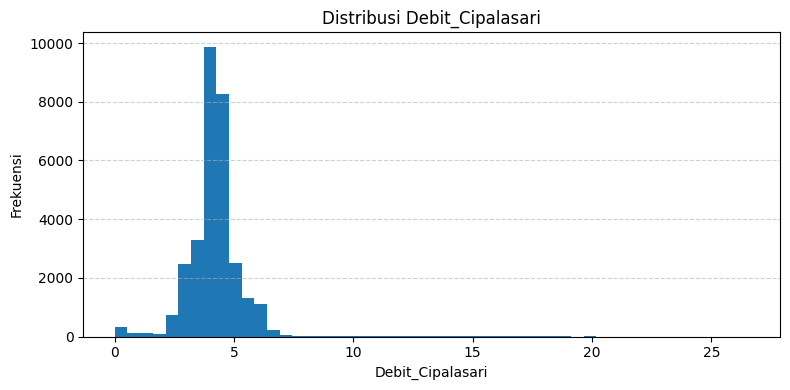

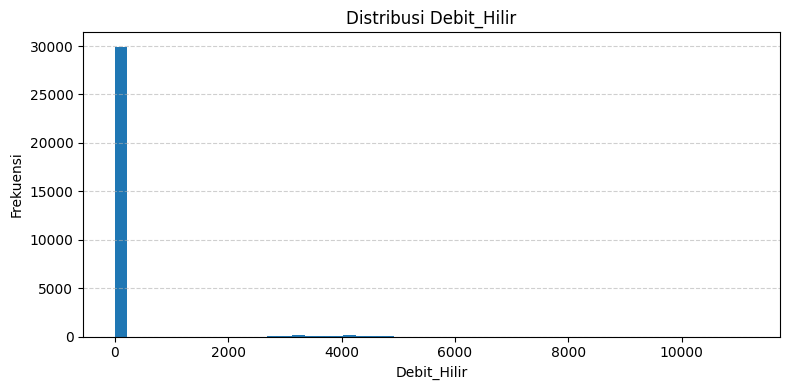

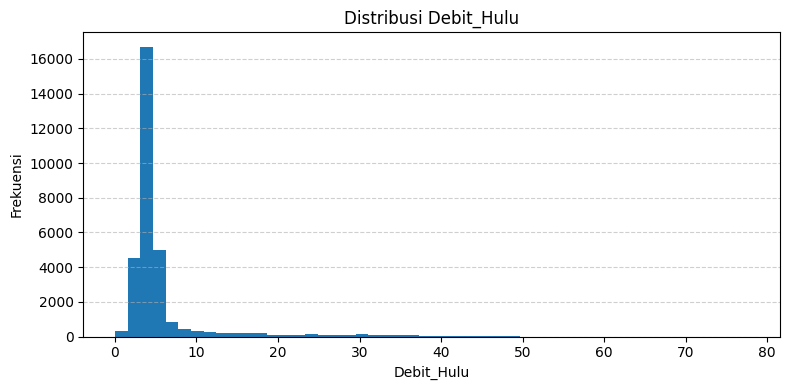

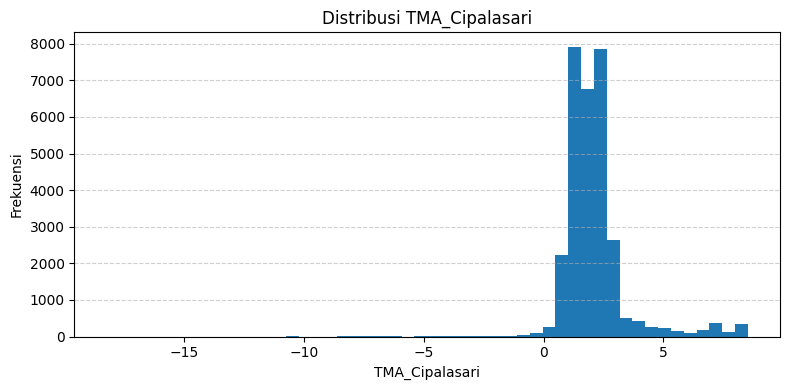

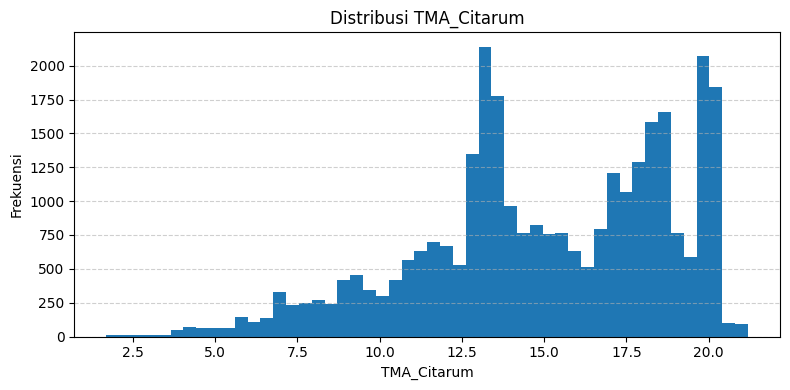

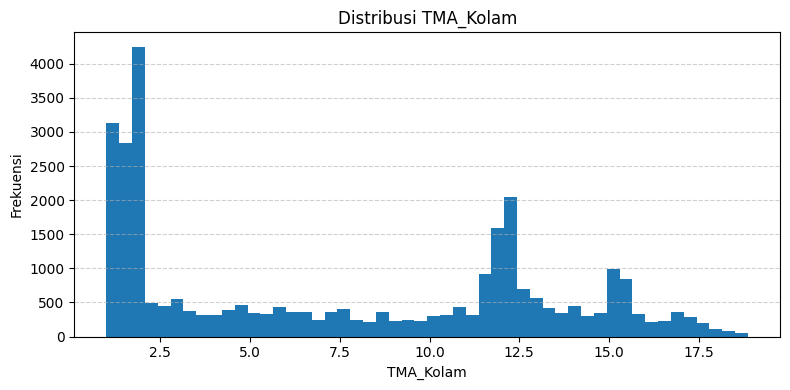

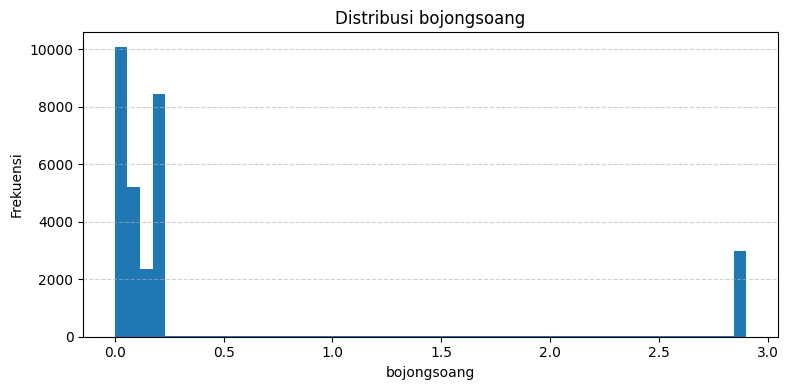

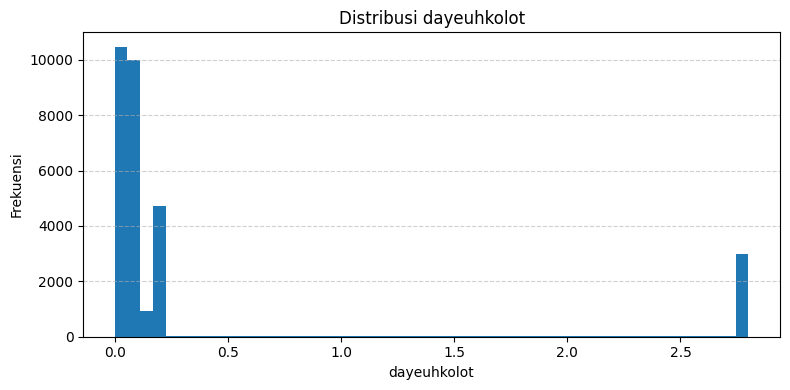

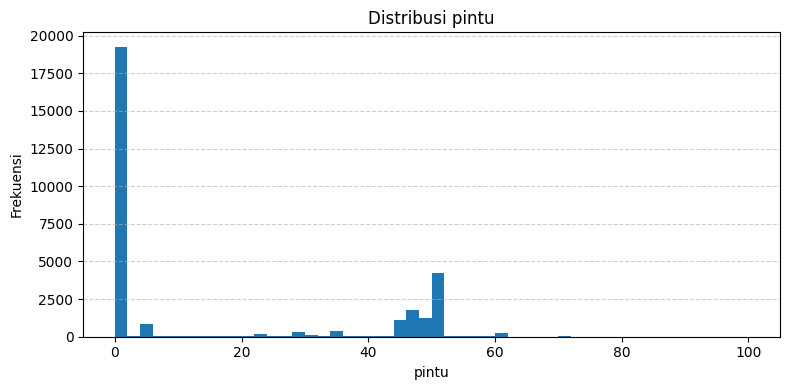

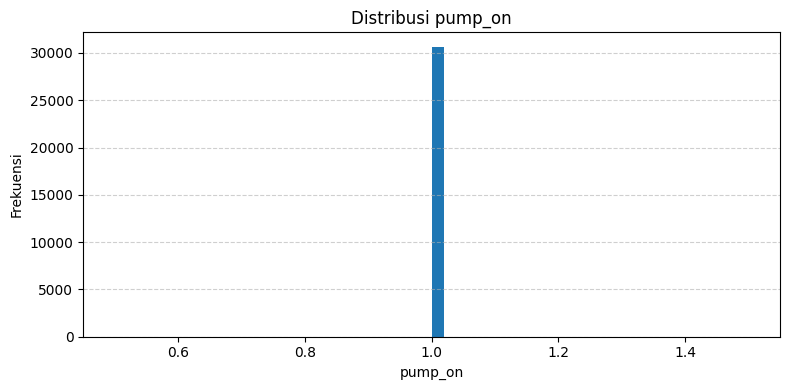

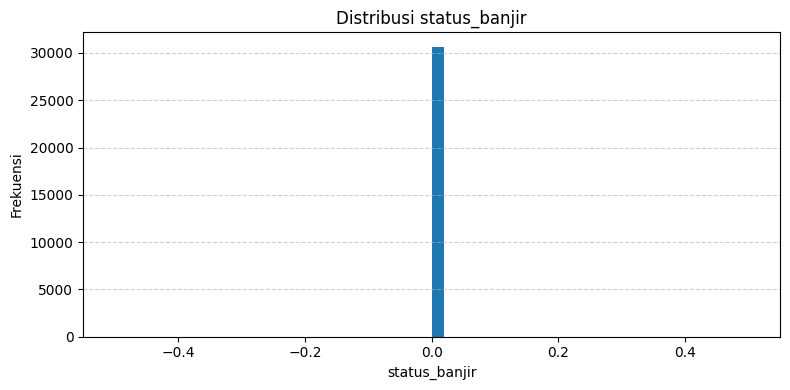

In [5]:
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col].dropna(), bins=50)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


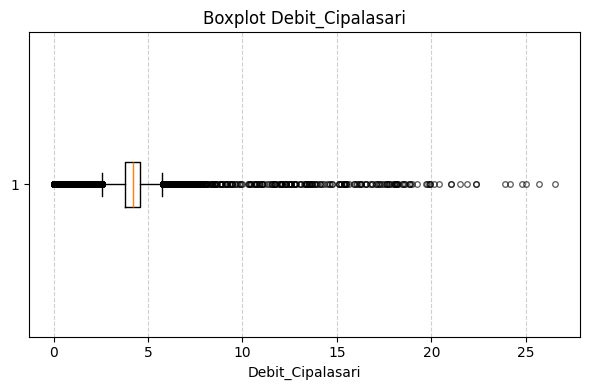

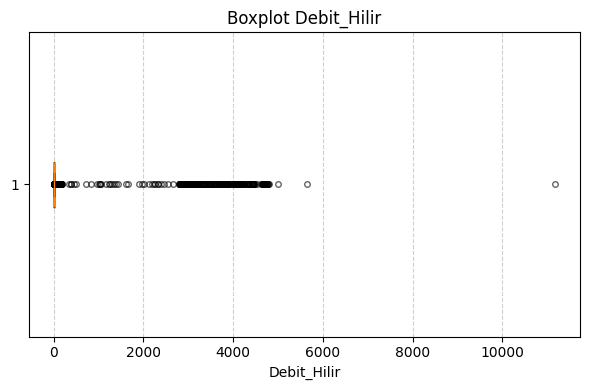

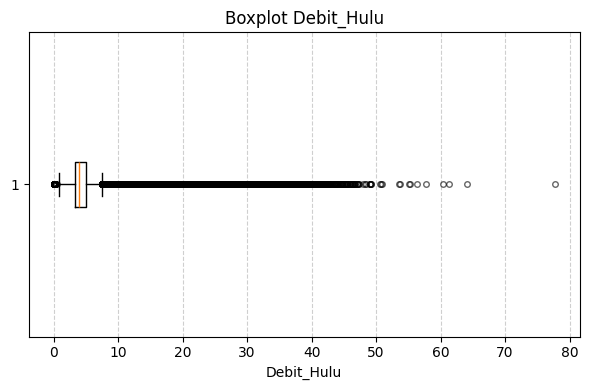

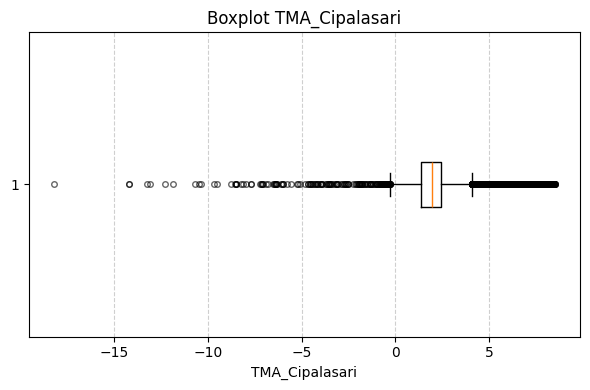

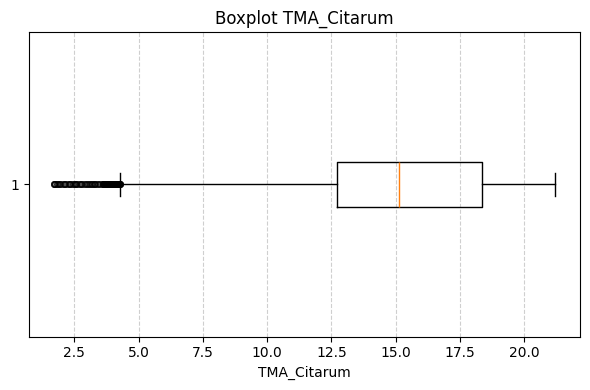

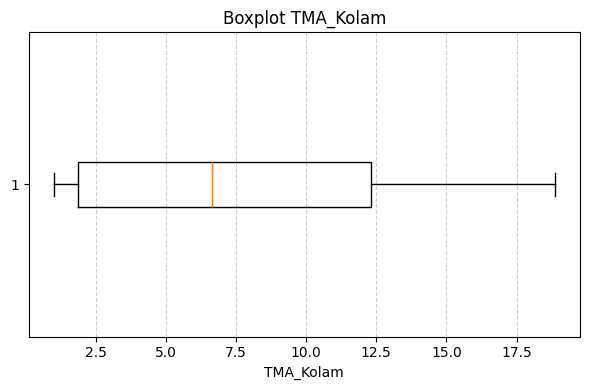

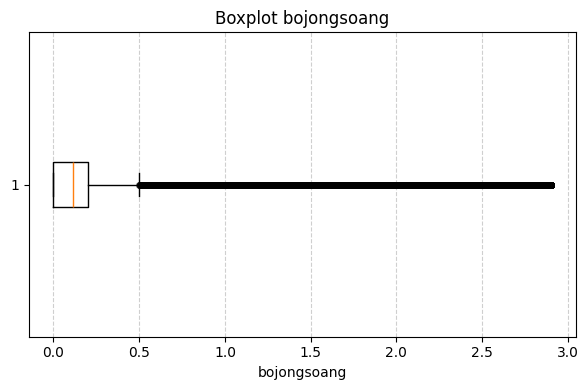

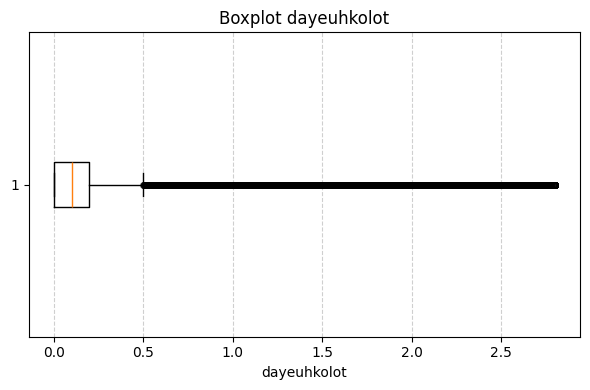

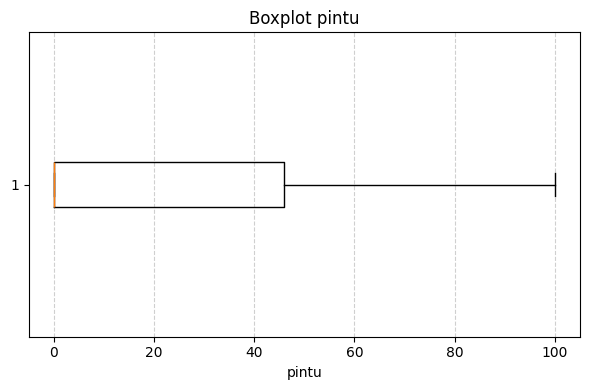

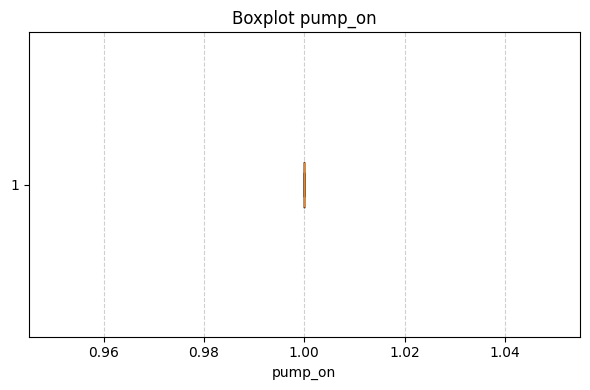

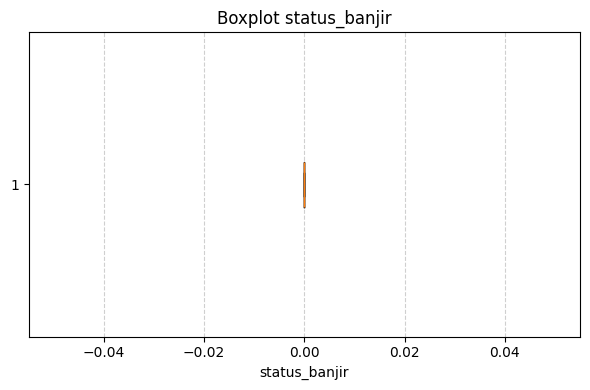

In [6]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col].dropna(), vert=False, showfliers=True,
                flierprops=dict(marker='o', markersize=4, alpha=0.6))
    plt.title(f'Boxplot {col}')
    plt.xlabel(col)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

Debit_Cipalasari_norm: skew=-0.6232, kurtosis=3.4655


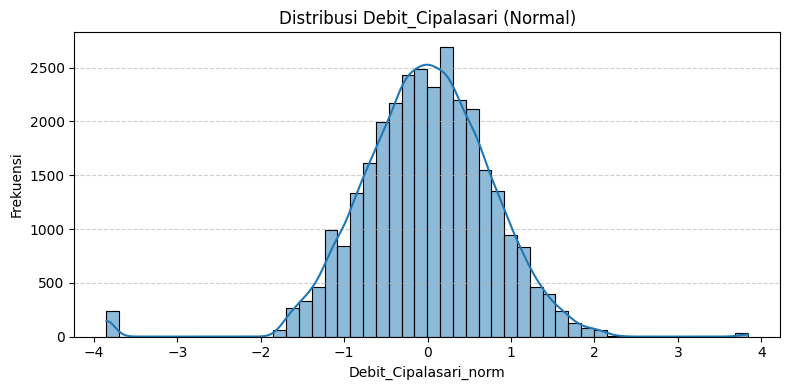

Debit_Hilir_norm: skew=-0.3928, kurtosis=2.6779


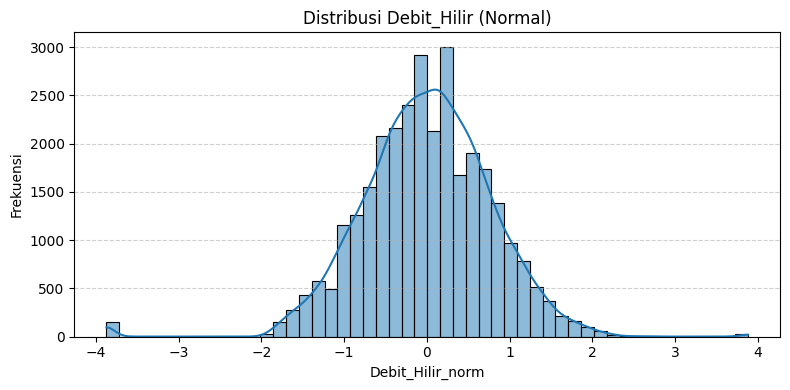

Debit_Hulu_norm: skew=-0.5652, kurtosis=3.2284


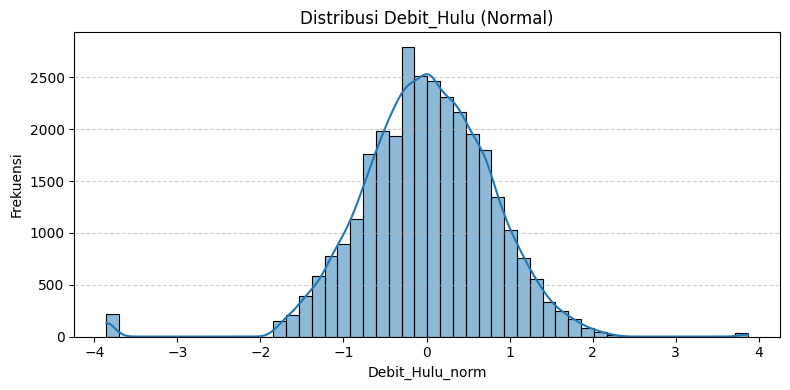

In [7]:
qt = QuantileTransformer(output_distribution='normal', random_state=42)
rs = RobustScaler()

# --- 1. Debit Cipalasari ---
df_copy['Debit_Cipalasari_log'] = np.log1p(df_copy['Debit_Cipalasari'])
low, high = df_copy['Debit_Cipalasari_log'].quantile([0.001, 0.999])
df_copy['Debit_Cipalasari_clip'] = df_copy['Debit_Cipalasari_log'].clip(low, high)
th = df_copy['Debit_Cipalasari'].quantile(0.95)
df_copy['high_flow_flag'] = (df_copy['Debit_Cipalasari'] > th).astype(int)
df_copy['Debit_Cipalasari_qt'] = qt.fit_transform(df_copy[['Debit_Cipalasari_clip']])
df_copy['Debit_Cipalasari_norm'] = rs.fit_transform(df_copy[['Debit_Cipalasari_qt']])
print(f"Debit_Cipalasari_norm: skew={df_copy['Debit_Cipalasari_norm'].skew():.4f}, "
      f"kurtosis={df_copy['Debit_Cipalasari_norm'].kurtosis():.4f}")
plt.figure(figsize=(8,4))
sns.histplot(df_copy['Debit_Cipalasari_norm'], bins=50, kde=True)
plt.title('Distribusi Debit_Cipalasari (Normal)')
plt.xlabel('Debit_Cipalasari_norm')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- 2. Debit Hilir ---
df_copy['Debit_Hilir_log'] = np.log1p(df_copy['Debit_Hilir'])
low, high = df_copy['Debit_Hilir_log'].quantile([0.001, 0.999])
df_copy['Debit_Hilir_clip'] = df_copy['Debit_Hilir_log'].clip(low, high)
th = df_copy['Debit_Hilir'].quantile(0.95)
df_copy['high_flow_hilir'] = (df_copy['Debit_Hilir'] > th).astype(int)
df_copy['Debit_Hilir_qt'] = qt.fit_transform(df_copy[['Debit_Hilir_clip']])
df_copy['Debit_Hilir_norm'] = rs.fit_transform(df_copy[['Debit_Hilir_qt']])
print(f"Debit_Hilir_norm: skew={df_copy['Debit_Hilir_norm'].skew():.4f}, "
      f"kurtosis={df_copy['Debit_Hilir_norm'].kurtosis():.4f}")
plt.figure(figsize=(8,4))
sns.histplot(df_copy['Debit_Hilir_norm'], bins=50, kde=True)
plt.title('Distribusi Debit_Hilir (Normal)')
plt.xlabel('Debit_Hilir_norm')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- 3. Debit Hulu ---
df_copy['Debit_Hulu_log'] = np.log1p(df_copy['Debit_Hulu'])
low, high = df_copy['Debit_Hulu_log'].quantile([0.001, 0.999])
df_copy['Debit_Hulu_clip'] = df_copy['Debit_Hulu_log'].clip(low, high)
th = df_copy['Debit_Hulu'].quantile(0.95)
df_copy['high_flow_hulu'] = (df_copy['Debit_Hulu'] > th).astype(int)
df_copy['Debit_Hulu_qt'] = qt.fit_transform(df_copy[['Debit_Hulu_clip']])
df_copy['Debit_Hulu_norm'] = rs.fit_transform(df_copy[['Debit_Hulu_qt']])
print(f"Debit_Hulu_norm: skew={df_copy['Debit_Hulu_norm'].skew():.4f}, "
      f"kurtosis={df_copy['Debit_Hulu_norm'].kurtosis():.4f}")
plt.figure(figsize=(8,4))
sns.histplot(df_copy['Debit_Hulu_norm'], bins=50, kde=True)
plt.title('Distribusi Debit_Hulu (Normal)')
plt.xlabel('Debit_Hulu_norm')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [8]:
df_copy.head()

,timestamp,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,Pump1,Pump2,Pump3,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,...,Debit_Hilir_log,Debit_Hilir_clip,high_flow_hilir,Debit_Hilir_qt,Debit_Hilir_norm,Debit_Hulu_log,Debit_Hulu_clip,high_flow_hulu,Debit_Hulu_qt,Debit_Hulu_norm
0,2025-06-09 00:00:00,0.466032,2.389919,1.819317,on,on,off,0.634561,6.569780,12.875024,...,1.220806,1.220806,0,-2.321682,-1.727226,1.036495,1.036495,0,-2.293272,-1.695403
1,2025-06-09 00:02:27,0.470409,2.398388,1.836405,on,on,off,0.629908,6.559635,12.874414,...,1.223301,1.223301,0,-2.320452,-1.726308,1.042537,1.042537,0,-2.290062,-1.693017
2,2025-06-09 00:07:27,0.479342,2.415673,1.871278,on,on,off,0.620411,6.538929,12.873169,...,1.228374,1.228374,0,-2.317962,-1.724451,1.054757,1.054757,0,-2.264140,-1.673759
3,2025-06-09 00:12:27,0.488275,2.432957,1.906150,on,on,off,0.610914,6.518223,12.871923,...,1.233422,1.233422,0,-2.315499,-1.722613,1.066829,1.066829,0,-2.228444,-1.647239
4,2025-06-09 00:17:27,0.497208,2.450241,1.941023,on,on,off,0.601418,6.497517,12.870678,...,1.238444,1.238444,0,-2.313062,-1.720795,1.078758,1.078758,0,-2.205577,-1.630250


Skewness: 0.005161027730337363
Kurtosis: 5.40140160321911


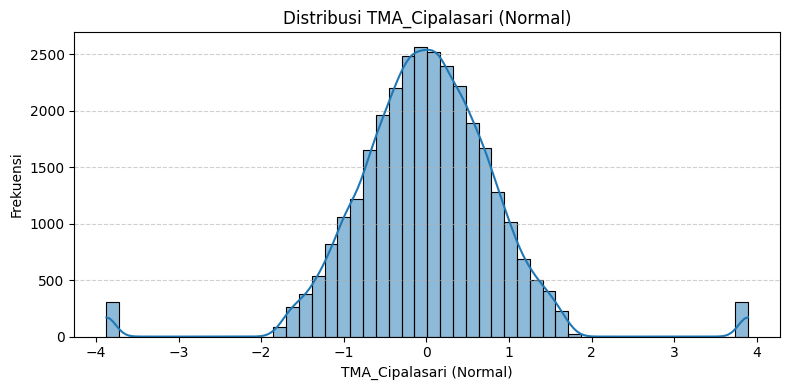

In [9]:
pt = PowerTransformer(method='yeo-johnson', standardize=False)
df_copy['TMA_Cip_pt'] = pt.fit_transform(df_copy[['TMA_Cipalasari']])

# 3. Winsorize pada persentil 1%–99% untuk buang noise ekstrem
low, high = df_copy['TMA_Cip_pt'].quantile([0.01, 0.99])
df_copy['TMA_Cip_clip'] = df_copy['TMA_Cip_pt'].clip(low, high)

# 4. Flag “high tide” (>95-persentil asli)
thr = df_copy['TMA_Cipalasari'].quantile(0.95)
df_copy['high_tide_flag'] = (df_copy['TMA_Cipalasari'] > thr).astype(int)

# 5. QuantileTransformer → distribusi Gaussian
qt = QuantileTransformer(output_distribution='normal', random_state=42)
df_copy['TMA_Cip_qt'] = qt.fit_transform(df_copy[['TMA_Cip_clip']])

# 6. RobustScaler → median=0, IQR=1
rs = RobustScaler()
df_copy['TMA_Cip_norm'] = rs.fit_transform(df_copy[['TMA_Cip_qt']])

# (Opsional) Cek skewness & kurtosis
from scipy.stats import skew, kurtosis
print("Skewness:", skew(df_copy['TMA_Cip_norm']))
print("Kurtosis:", kurtosis(df_copy['TMA_Cip_norm']))

plt.figure(figsize=(8, 4))
sns.histplot(df_copy['TMA_Cip_norm'], bins=50, kde=True)
plt.title('Distribusi TMA_Cipalasari (Normal)')
plt.xlabel('TMA_Cipalasari (Normal)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Skewness: 0.2463374718382723
Kurtosis: 5.742268178632703


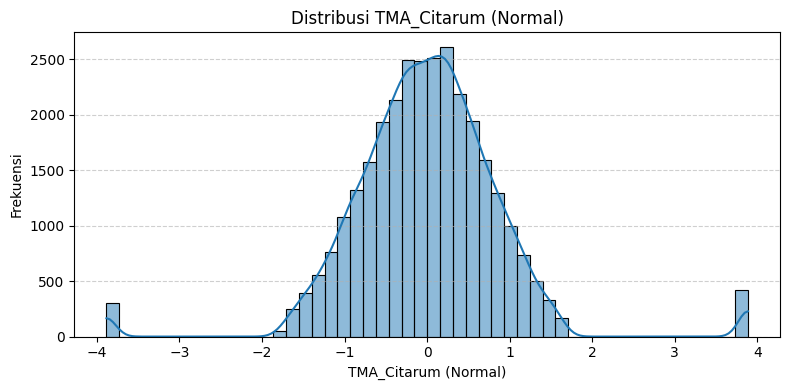

In [10]:
pt = PowerTransformer(method='yeo-johnson', standardize=False)
df_copy['TMA_Cit_pt'] = pt.fit_transform(df_copy[['TMA_Citarum']])

# 3. Winsorize di persentil 1%–99% untuk buang noise ekstrem
low, high = df_copy['TMA_Cit_pt'].quantile([0.01, 0.99])
df_copy['TMA_Cit_clip'] = df_copy['TMA_Cit_pt'].clip(low, high)

# 4. Indikator “high tide” >95-persentil asli
thr_cit = df_copy['TMA_Citarum'].quantile(0.95)
df_copy['high_tide_cit'] = (df_copy['TMA_Citarum'] > thr_cit).astype(int)

# 5. QuantileTransformer → paksa distribusi Gaussian
qt = QuantileTransformer(output_distribution='normal', random_state=42)
df_copy['TMA_Cit_qt'] = qt.fit_transform(df_copy[['TMA_Cit_clip']])

# 6. RobustScaler → median=0, IQR=1
rs = RobustScaler()
df_copy['TMA_Cit_norm'] = rs.fit_transform(df_copy[['TMA_Cit_qt']])

# 7. Verifikasi skewness & kurtosis
print("Skewness:", skew(df_copy['TMA_Cit_norm']))
print("Kurtosis:", kurtosis(df_copy['TMA_Cit_norm']))

plt.figure(figsize=(8, 4))
sns.histplot(df_copy['TMA_Cit_norm'], bins=50, kde=True)
plt.title('Distribusi TMA_Citarum (Normal)')
plt.xlabel('TMA_Citarum (Normal)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Skewness: -0.0766325079465525
Kurtosis: 5.670925340787665


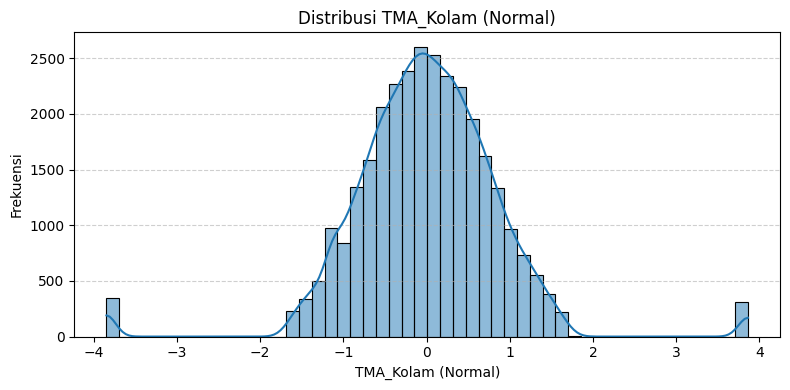

In [11]:
pt = PowerTransformer(method='yeo-johnson', standardize=False)
df_copy['TMA_Kolam_pt'] = pt.fit_transform(df_copy[['TMA_Kolam']])

# 3. Winsorize (clip) pada persentil 1%–99% untuk buang noise ekstrem
low, high = df_copy['TMA_Kolam_pt'].quantile([0.01, 0.99])
df_copy['TMA_Kolam_clip'] = df_copy['TMA_Kolam_pt'].clip(low, high)

# 4. Indikator “high water” (>95-persentil asli)
thr_kolam = df_copy['TMA_Kolam'].quantile(0.95)
df_copy['high_water_flag'] = (df_copy['TMA_Kolam'] > thr_kolam).astype(int)

# 5. QuantileTransformer → memaksa distribusi mendekati Gaussian
qt = QuantileTransformer(output_distribution='normal', random_state=42)
df_copy['TMA_Kolam_qt'] = qt.fit_transform(df_copy[['TMA_Kolam_clip']])

# 6. RobustScaler → median=0, IQR=1, tahan outlier tersisa
rs = RobustScaler()
df_copy['TMA_Kolam_norm'] = rs.fit_transform(df_copy[['TMA_Kolam_qt']])

# 7. Cek skewness & kurtosis pasca‐transformasi
print("Skewness:", skew(df_copy['TMA_Kolam_norm']))
print("Kurtosis:", kurtosis(df_copy['TMA_Kolam_norm']))

plt.figure(figsize=(8, 4))
sns.histplot(df_copy['TMA_Kolam_norm'], bins=50, kde=True)
plt.title('Distribusi TMA_Kolam (Normal)')
plt.xlabel('TMA_Kolam (Normal)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Skewness: -0.08194453785254652
Kurtosis: -0.47729809375787724


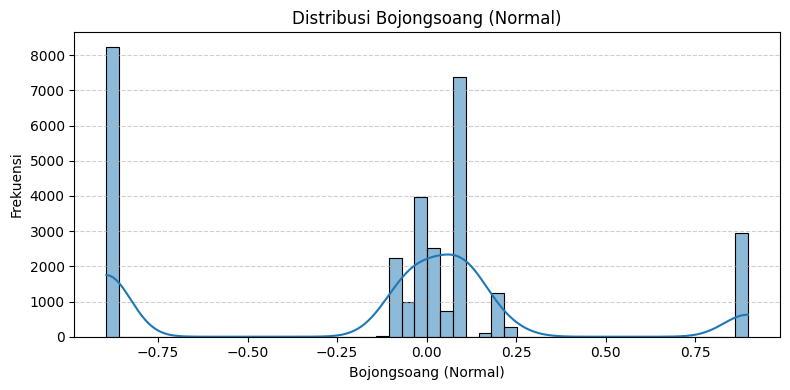

In [12]:
df_copy['bojongsoang_log'] = np.log1p(df_copy['bojongsoang'])

# 2. Winsorize (clip) pada persentil 0.1%–99.9% untuk buang noise ekstrem
lower = df_copy['bojongsoang_log'].quantile(0.001)
upper = df_copy['bojongsoang_log'].quantile(0.999)
df_copy['bojongsoang_clip'] = df_copy['bojongsoang_log'].clip(lower, upper)

# 3. Indikator peristiwa hujan besar (>95 persentil asli)
threshold_bojong = df_copy['bojongsoang'].quantile(0.95)
df_copy['rain_flag_bojong'] = (df_copy['bojongsoang'] > threshold_bojong).astype(int)

# 4. QuantileTransformer → paksa distribusi mendekati Gaussian
qt = QuantileTransformer(output_distribution='normal', random_state=42)
df_copy['bojongsoang_qt'] = qt.fit_transform(df_copy[['bojongsoang_clip']])

# 5. RobustScaler → skala median=0, IQR=1 (tahan outlier tersisa)
rs = RobustScaler()
df_copy['bojongsoang_norm'] = rs.fit_transform(df_copy[['bojongsoang_qt']])

# 6. Verifikasi skewness & kurtosis pasca‐transformasi
print("Skewness:", skew(df_copy['bojongsoang_norm']))
print("Kurtosis:", kurtosis(df_copy['bojongsoang_norm']))

plt.figure(figsize=(8, 4))
sns.histplot(df_copy['bojongsoang_norm'], bins=50, kde=True)
plt.title('Distribusi Bojongsoang (Normal)')
plt.xlabel('Bojongsoang (Normal)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Skewness: -0.0846266843755107
Kurtosis: -0.4815101785693505


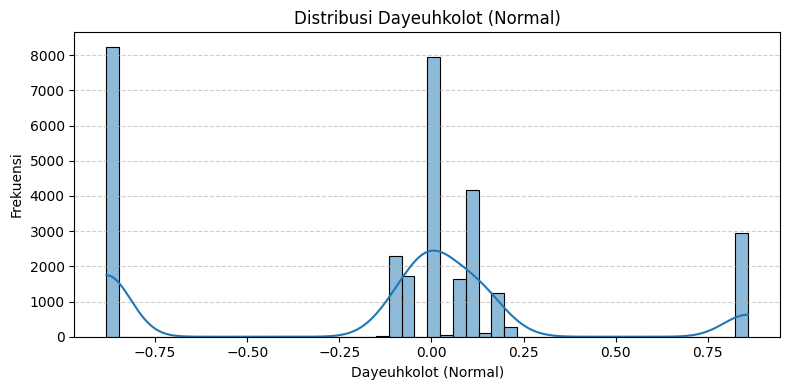

In [13]:
df_copy['dayeuhkolot_log'] = np.log1p(df_copy['dayeuhkolot'])

# 2. Winsorize (clip) pada persentil 0.1%–99.9%
lower = df_copy['dayeuhkolot_log'].quantile(0.001)
upper = df_copy['dayeuhkolot_log'].quantile(0.999)
df_copy['dayeuhkolot_clip'] = df_copy['dayeuhkolot_log'].clip(lower, upper)

# 3. Indikator peristiwa hujan besar (>95-persentil asli)
thr_day = df_copy['dayeuhkolot'].quantile(0.95)
df_copy['rain_flag_day'] = (df_copy['dayeuhkolot'] > thr_day).astype(int)

# 4. QuantileTransformer → paksa distribusi mendekati Gaussian
qt = QuantileTransformer(output_distribution='normal', random_state=42)
df_copy['dayeuhkolot_qt'] = qt.fit_transform(df_copy[['dayeuhkolot_clip']])

# 5. RobustScaler → skala median=0, IQR=1 (tahan outlier sisa)
rs = RobustScaler()
df_copy['dayeuhkolot_norm'] = rs.fit_transform(df_copy[['dayeuhkolot_qt']])

# 6. Verifikasi skewness & kurtosis pasca‐transformasi
print("Skewness:", skew(df_copy['dayeuhkolot_norm']))
print("Kurtosis:", kurtosis(df_copy['dayeuhkolot_norm']))

plt.figure(figsize=(8, 4))
sns.histplot(df_copy['dayeuhkolot_norm'], bins=50, kde=True)
plt.title('Distribusi Dayeuhkolot (Normal)')
plt.xlabel('Dayeuhkolot (Normal)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [14]:
df_copy.drop('timestamp', axis=1, inplace=True)
df_copy.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,Pump1,Pump2,Pump3,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,...,bojongsoang_log,bojongsoang_clip,rain_flag_bojong,bojongsoang_qt,bojongsoang_norm,dayeuhkolot_log,dayeuhkolot_clip,rain_flag_day,dayeuhkolot_qt,dayeuhkolot_norm
0,0.466032,2.389919,1.819317,on,on,off,0.634561,6.569780,12.875024,0.0,...,0.0,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862
1,0.470409,2.398388,1.836405,on,on,off,0.629908,6.559635,12.874414,0.0,...,0.0,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862
2,0.479342,2.415673,1.871278,on,on,off,0.620411,6.538929,12.873169,0.0,...,0.0,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862
3,0.488275,2.432957,1.906150,on,on,off,0.610914,6.518223,12.871923,0.0,...,0.0,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862
4,0.497208,2.450241,1.941023,on,on,off,0.601418,6.497517,12.870678,0.0,...,0.0,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862


In [15]:
df_copy['pump'] = df_copy[['Pump1', 'Pump2', 'Pump3']].eq('on').sum(axis=1)
df_copy.drop(columns=['Pump1', 'Pump2', 'Pump3'], inplace=True)
df_copy.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,pintu,pump_on,...,bojongsoang_clip,rain_flag_bojong,bojongsoang_qt,bojongsoang_norm,dayeuhkolot_log,dayeuhkolot_clip,rain_flag_day,dayeuhkolot_qt,dayeuhkolot_norm,pump
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,0.0,0.0,0.0,1.0,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,0.0,0.0,0.0,1.0,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,0.0,0.0,0.0,1.0,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,0.0,0.0,0.0,1.0,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,0.0,0.0,0.0,1.0,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2


In [16]:
df_copy.drop(columns=['pump_on', 'status_banjir', 'pintu'], inplace=True)
df_copy.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,Debit_Cipalasari_log,Debit_Cipalasari_clip,...,bojongsoang_clip,rain_flag_bojong,bojongsoang_qt,bojongsoang_norm,dayeuhkolot_log,dayeuhkolot_clip,rain_flag_day,dayeuhkolot_qt,dayeuhkolot_norm,pump
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,0.0,0.0,0.382560,0.382560,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,0.0,0.0,0.385541,0.385541,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,0.0,0.0,0.391598,0.391598,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,0.0,0.0,0.397618,0.397618,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,0.0,0.0,0.403602,0.403602,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2


                 variant  skewness   kurtosis           test  p_value
0       Debit_Cipalasari  4.244257  51.235797  D’Agostino K²      0.0
1   Debit_Cipalasari_log -2.325098  17.694479  D’Agostino K²      0.0
2  Debit_Cipalasari_clip -2.390804  17.554739  D’Agostino K²      0.0
3    Debit_Cipalasari_qt -0.623234   3.465545  D’Agostino K²      0.0
4  Debit_Cipalasari_norm -0.623234   3.465545  D’Agostino K²      0.0


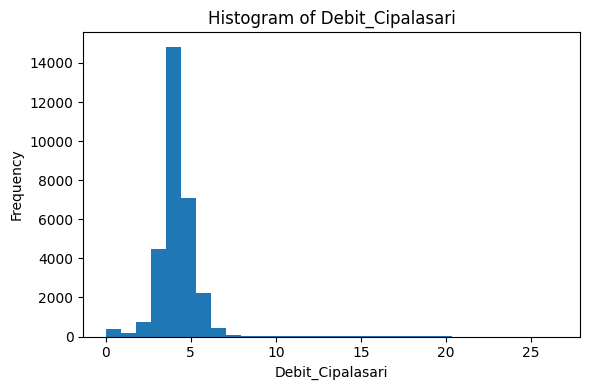

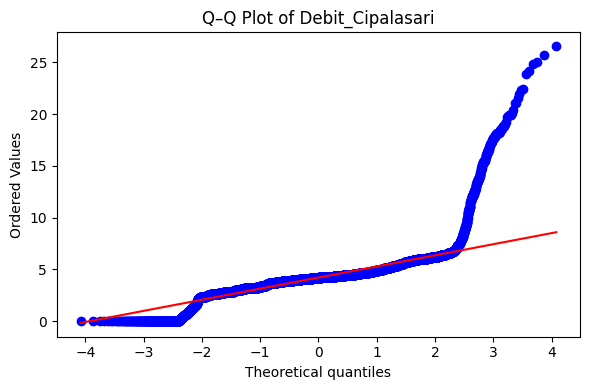

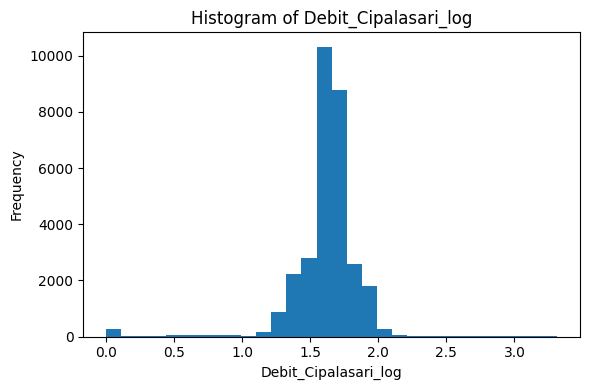

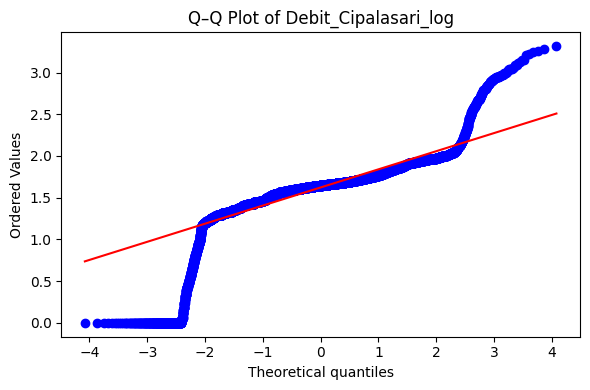

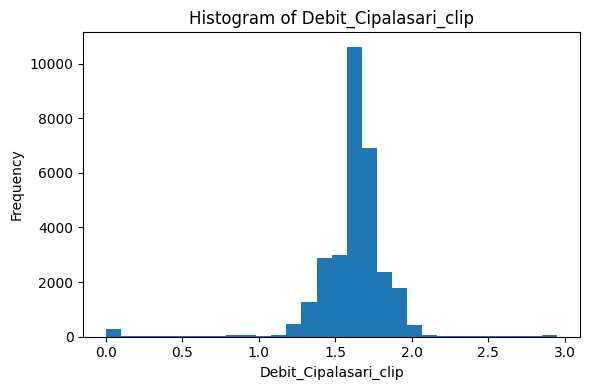

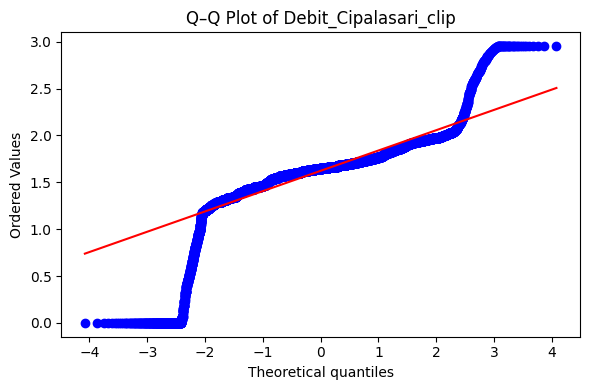

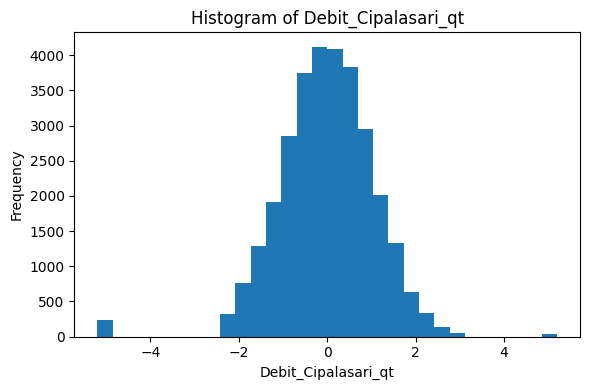

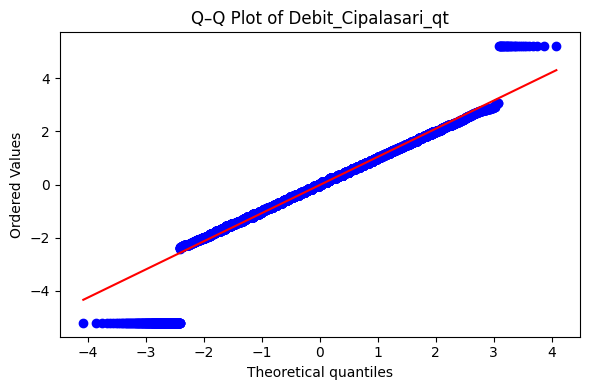

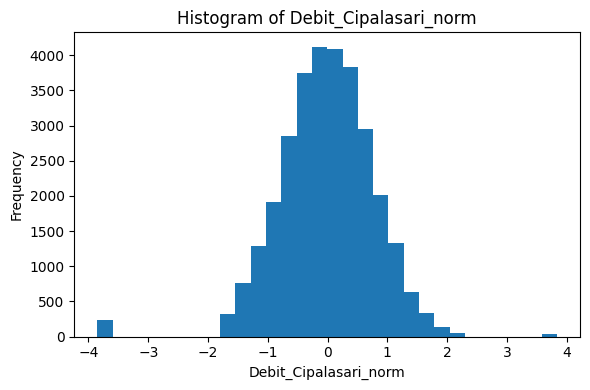

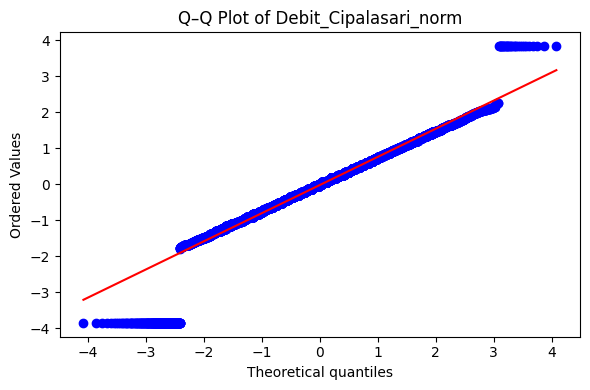

In [17]:

# 2. Definisikan kolom dan variannya
var = 'Debit_Cipalasari'
variants = [
    var,
    f'{var}_log',
    f'{var}_clip',
    f'{var}_qt',
    f'{var}_norm'
]

# 3. Hitung skewness, kurtosis, dan normality test
results = []
for col in variants:
    data = df_copy[col].dropna()
    skew = data.skew()
    kurt = data.kurtosis()
    if len(data) <= 5000:
        stat, p = stats.shapiro(data)
        test = 'Shapiro–Wilk'
    else:
        stat, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    results.append({
        'variant': col,
        'skewness': skew,
        'kurtosis': kurt,
        'test': test,
        'p_value': p
    })

results_df = pd.DataFrame(results)
print(results_df)

# 4. Visualisasi histogram dan Q–Q plot
for col in variants:
    data = df_copy[col].dropna()
    plt.figure(figsize=(6,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col); plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f'Q–Q Plot of {col}')
    plt.tight_layout()
    plt.show()


            variant  skewness   kurtosis           test  p_value
0       Debit_Hilir  6.687787  46.186896  D’Agostino K²      0.0
1   Debit_Hilir_log  5.364799  30.363821  D’Agostino K²      0.0
2  Debit_Hilir_clip  5.362956  30.342660  D’Agostino K²      0.0
3    Debit_Hilir_qt -0.392824   2.677918  D’Agostino K²      0.0
4  Debit_Hilir_norm -0.392824   2.677918  D’Agostino K²      0.0


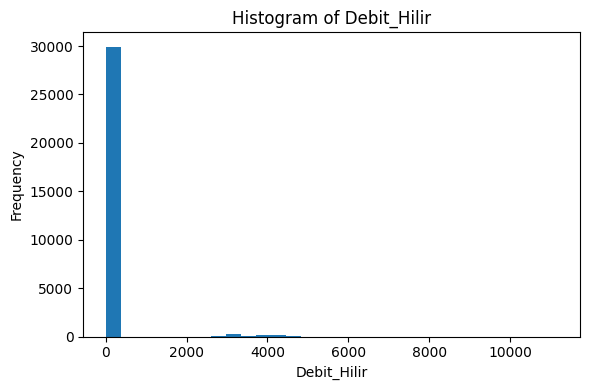

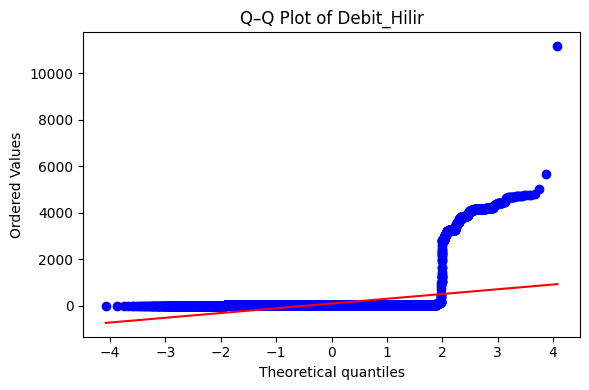

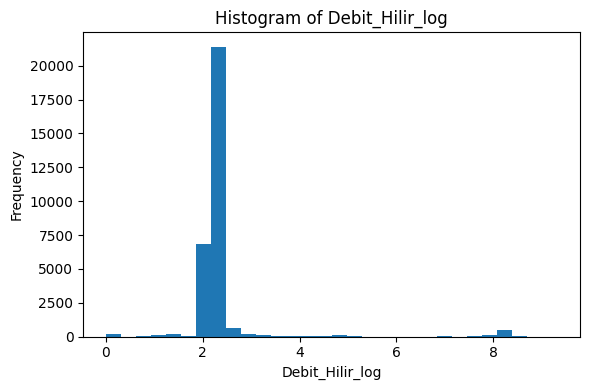

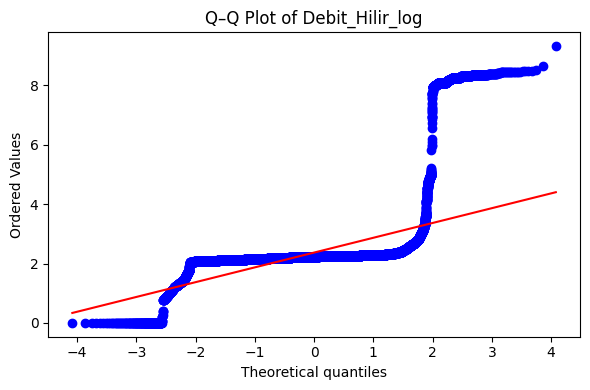

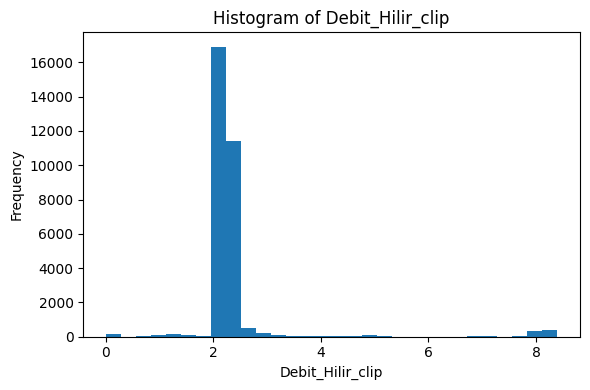

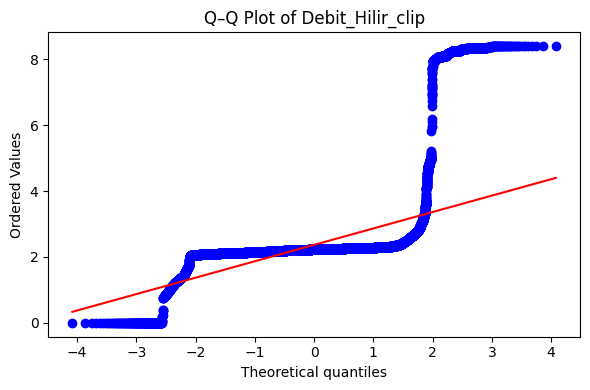

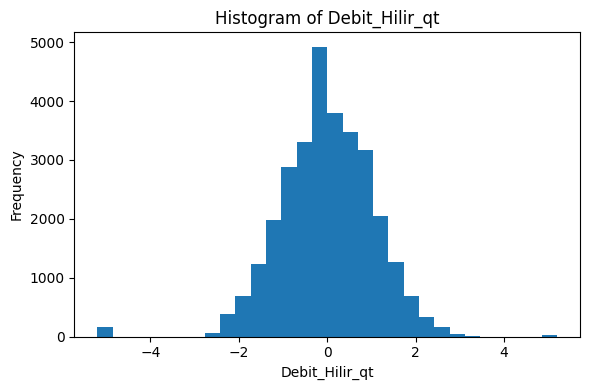

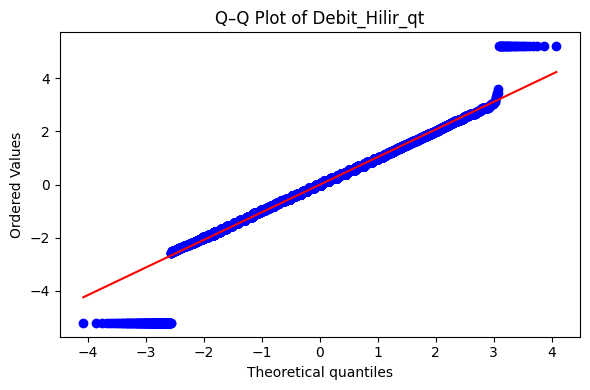

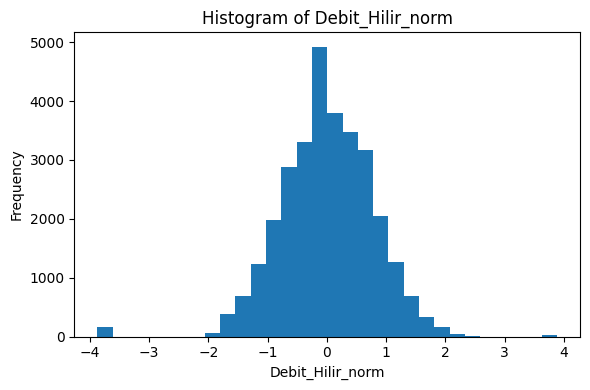

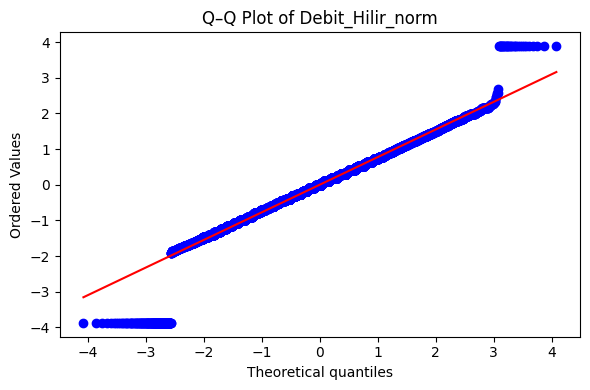

In [18]:

# 2. Definisikan kolom dan variannya
var = 'Debit_Hilir'
variants = [
    var,
    f'{var}_log',
    f'{var}_clip',
    f'{var}_qt',
    f'{var}_norm'
]

# 3. Hitung skewness, kurtosis, dan normality test
results = []
for col in variants:
    data = df_copy[col].dropna()
    skew = data.skew()
    kurt = data.kurtosis()
    if len(data) <= 5000:
        stat, p = stats.shapiro(data)
        test = 'Shapiro–Wilk'
    else:
        stat, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    results.append({
        'variant': col,
        'skewness': skew,
        'kurtosis': kurt,
        'test': test,
        'p_value': p
    })

results_df = pd.DataFrame(results)
print(results_df)

# 4. Visualisasi histogram dan Q–Q plot
for col in variants:
    data = df_copy[col].dropna()
    plt.figure(figsize=(6,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col); plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f'Q–Q Plot of {col}')
    plt.tight_layout()
    plt.show()


           variant  skewness   kurtosis           test  p_value
0       Debit_Hulu  3.919454  16.828376  D’Agostino K²      0.0
1   Debit_Hulu_log  1.742888   5.437909  D’Agostino K²      0.0
2  Debit_Hulu_clip  1.736284   5.398702  D’Agostino K²      0.0
3    Debit_Hulu_qt -0.565199   3.228372  D’Agostino K²      0.0
4  Debit_Hulu_norm -0.565199   3.228372  D’Agostino K²      0.0


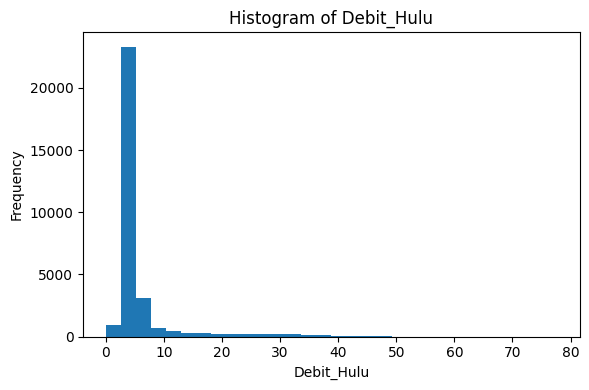

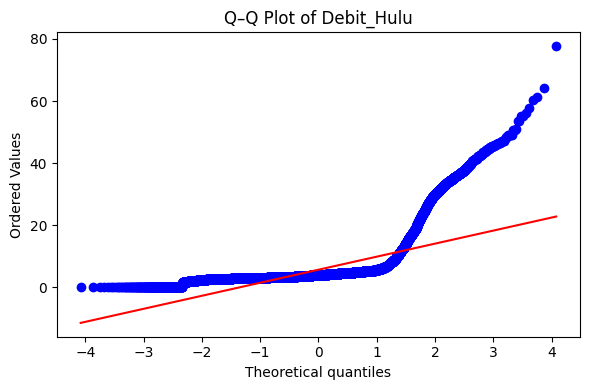

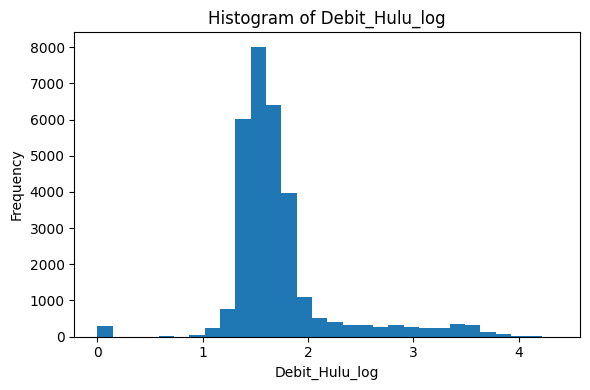

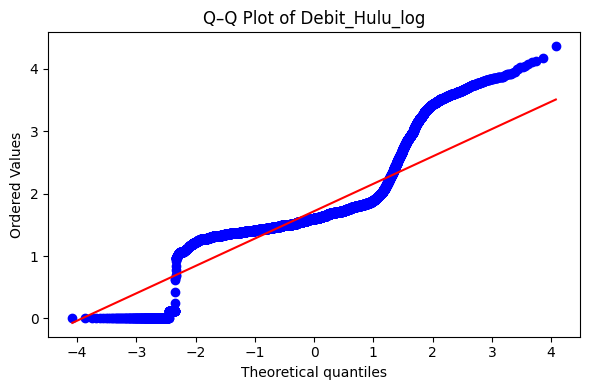

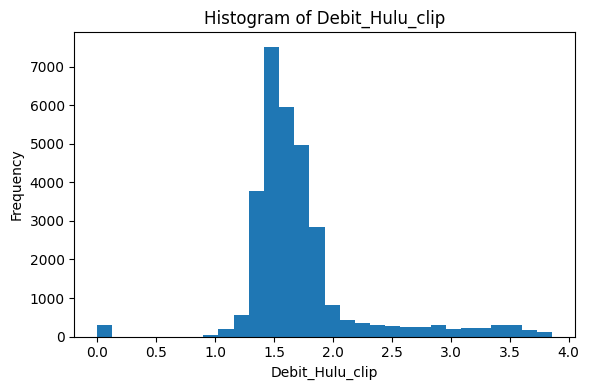

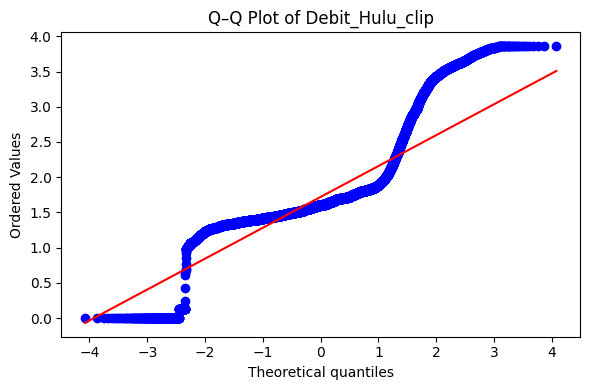

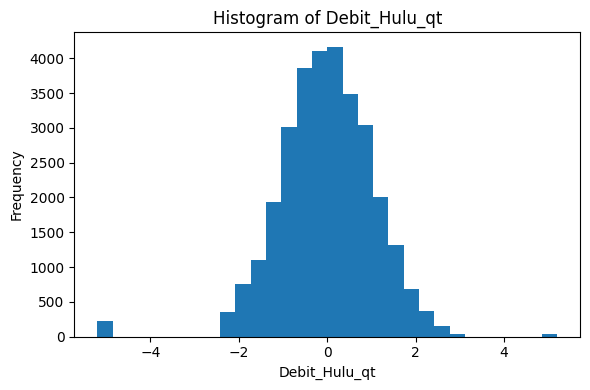

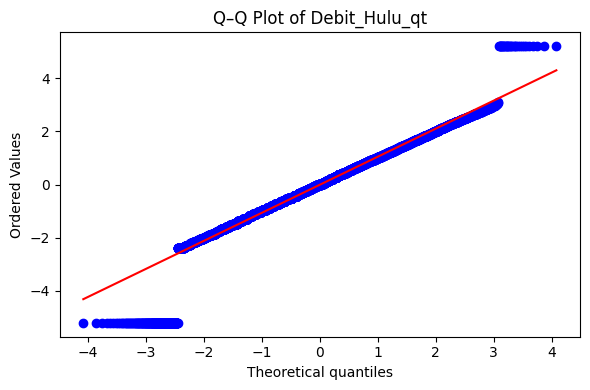

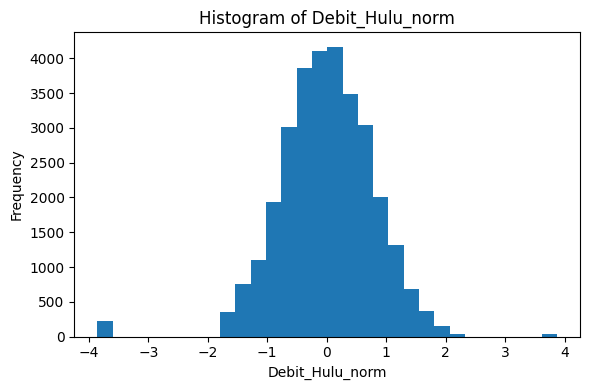

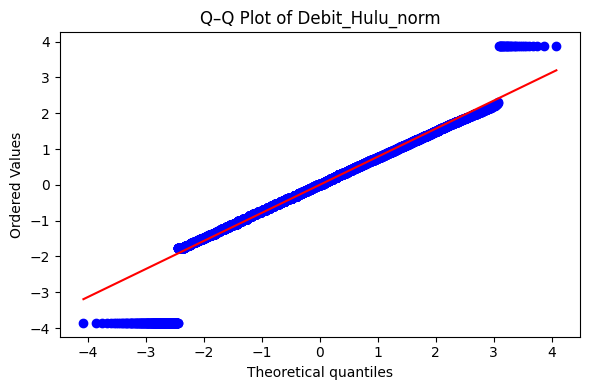

In [19]:

# 2. Definisikan kolom dan variannya
var = 'Debit_Hulu'
variants = [
    var,
    f'{var}_log',
    f'{var}_clip',
    f'{var}_qt',
    f'{var}_norm'
]

# 3. Hitung skewness, kurtosis, dan normality test
results = []
for col in variants:
    data = df_copy[col].dropna()
    skew = data.skew()
    kurt = data.kurtosis()
    if len(data) <= 5000:
        stat, p = stats.shapiro(data)
        test = 'Shapiro–Wilk'
    else:
        stat, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    results.append({
        'variant': col,
        'skewness': skew,
        'kurtosis': kurt,
        'test': test,
        'p_value': p
    })

results_df = pd.DataFrame(results)
print(results_df)

# 4. Visualisasi histogram dan Q–Q plot
for col in variants:
    data = df_copy[col].dropna()
    plt.figure(figsize=(6,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col); plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f'Q–Q Plot of {col}')
    plt.tight_layout()
    plt.show()


In [20]:
df_copy.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,Debit_Cipalasari_log,Debit_Cipalasari_clip,...,bojongsoang_clip,rain_flag_bojong,bojongsoang_qt,bojongsoang_norm,dayeuhkolot_log,dayeuhkolot_clip,rain_flag_day,dayeuhkolot_qt,dayeuhkolot_norm,pump
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,0.0,0.0,0.382560,0.382560,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,0.0,0.0,0.385541,0.385541,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,0.0,0.0,0.391598,0.391598,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,0.0,0.0,0.397618,0.397618,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,0.0,0.0,0.403602,0.403602,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2


In [21]:
rename_map = {
    'TMA_Cip_pt':   'TMA_Cipalasari_pt',
    'TMA_Cip_clip': 'TMA_Cipalasari_clip',
    'TMA_Cip_qt':   'TMA_Cipalasari_qt',
    'TMA_Cip_norm':'TMA_Cipalasari_norm',
    # dan seterusnya untuk TMA_Cit_* dan TMA_Kolam_*:
    'TMA_Cit_pt':   'TMA_Citarum_pt',
    'TMA_Cit_clip': 'TMA_Citarum_clip',
    'TMA_Cit_qt':   'TMA_Citarum_qt',
    'TMA_Cit_norm':'TMA_Citarum_norm',
}

df_copy.rename(columns=rename_map, inplace=True)
df_copy.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,Debit_Cipalasari_log,Debit_Cipalasari_clip,...,bojongsoang_clip,rain_flag_bojong,bojongsoang_qt,bojongsoang_norm,dayeuhkolot_log,dayeuhkolot_clip,rain_flag_day,dayeuhkolot_qt,dayeuhkolot_norm,pump
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,0.0,0.0,0.382560,0.382560,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,0.0,0.0,0.385541,0.385541,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,0.0,0.0,0.391598,0.391598,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,0.0,0.0,0.397618,0.397618,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,0.0,0.0,0.403602,0.403602,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2


               variant  skewness   kurtosis           test  p_value
0    TMA_Cipalasari_pt  0.499886  19.683905  D’Agostino K²      0.0
1  TMA_Cipalasari_norm  0.005161   5.402479  D’Agostino K²      0.0
2  TMA_Cipalasari_clip  2.388462   7.255902  D’Agostino K²      0.0
3    TMA_Cipalasari_qt  0.005161   5.402479  D’Agostino K²      0.0


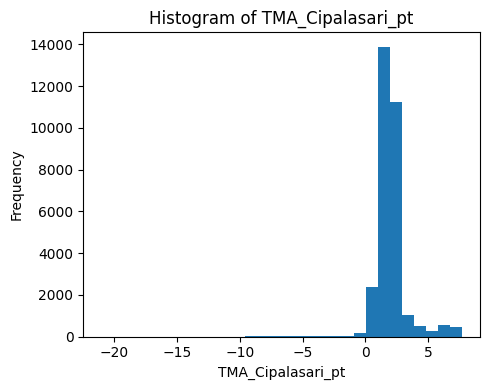

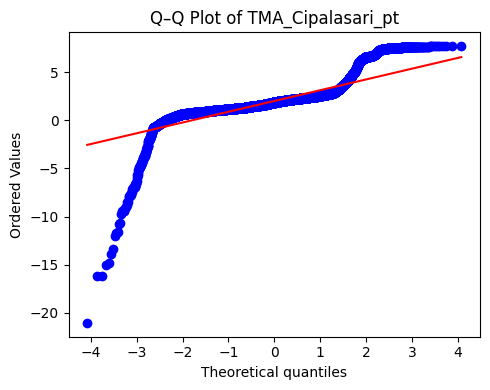

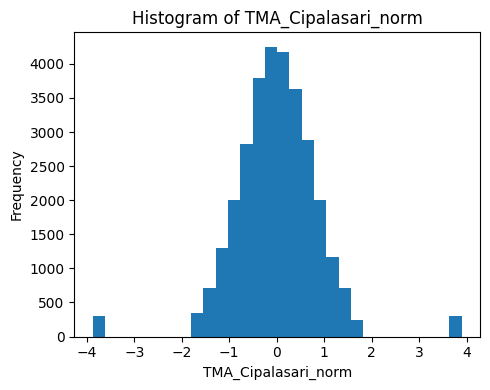

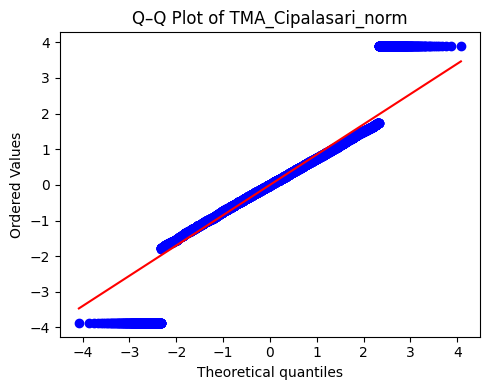

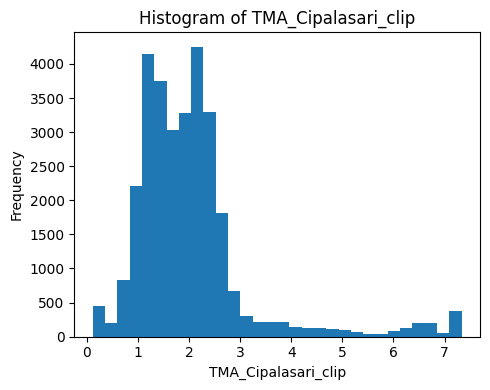

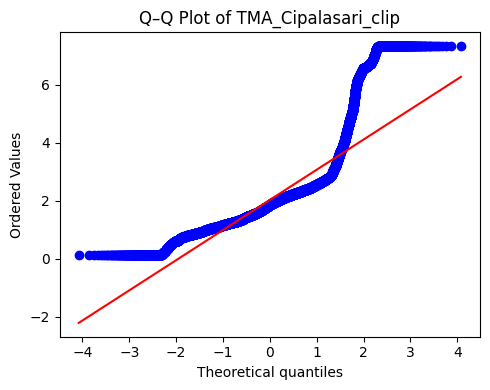

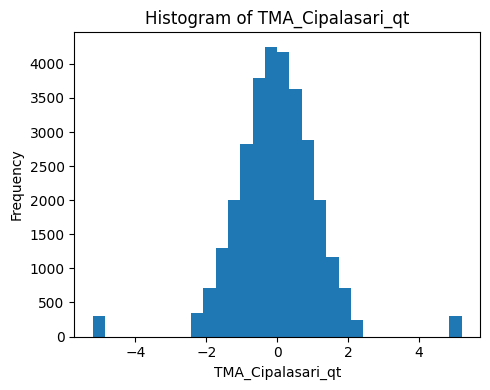

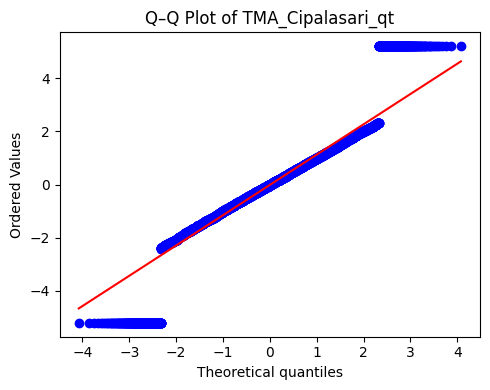

In [22]:
# 2. Pilih variants khusus untuk TMA_Cipalasari
var = 'TMA_Cipalasari'
variants = [
    f'{var}_pt',
    # f'{var}_log',
    f'{var}_norm',
    f'{var}_clip',
    f'{var}_qt'
]

# 3. Hitung skewness, kurtosis, dan normality test untuk tiap variant
results = []
for col in variants:
    data = df_copy[col].dropna()
    skew = data.skew()
    kurt = data.kurtosis()
    if len(data) <= 5000:
        _, p = stats.shapiro(data)
        test = 'Shapiro–Wilk'
    else:
        _, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    results.append({
        'variant': col,
        'skewness': skew,
        'kurtosis': kurt,
        'test': test,
        'p_value': p
    })

results_df = pd.DataFrame(results)
print(results_df)

# 4. Visualisasi histogram dan Q–Q plot
for col in variants:
    data = df_copy[col].dropna()

    plt.figure(figsize=(5,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col); plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5,4))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f'Q–Q Plot of {col}')
    plt.tight_layout()
    plt.show()


            variant  skewness  kurtosis           test  p_value
0    TMA_Citarum_pt -0.162335 -0.966450  D’Agostino K²      0.0
1  TMA_Citarum_norm  0.246350  5.743401  D’Agostino K²      0.0
2  TMA_Citarum_clip -0.152687 -1.005162  D’Agostino K²      0.0
3    TMA_Citarum_qt  0.246350  5.743401  D’Agostino K²      0.0


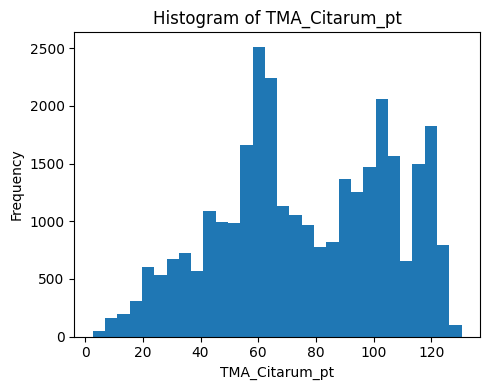

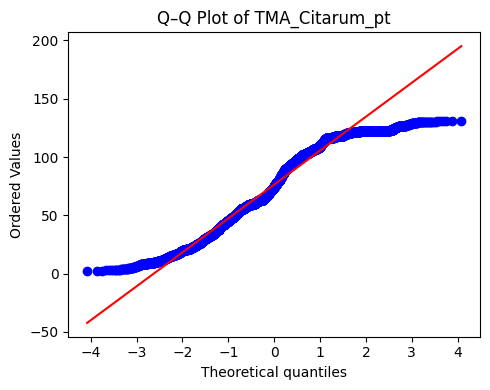

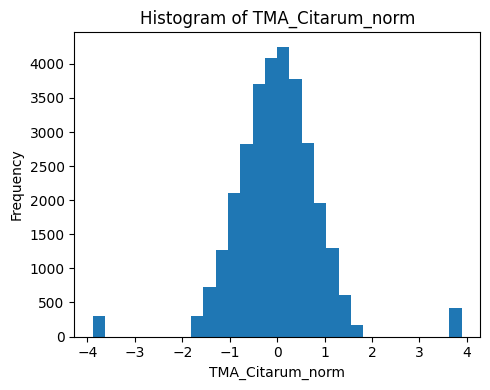

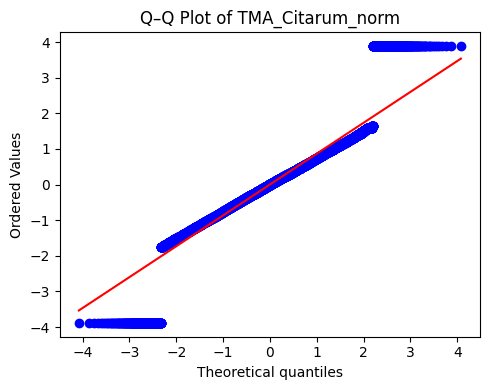

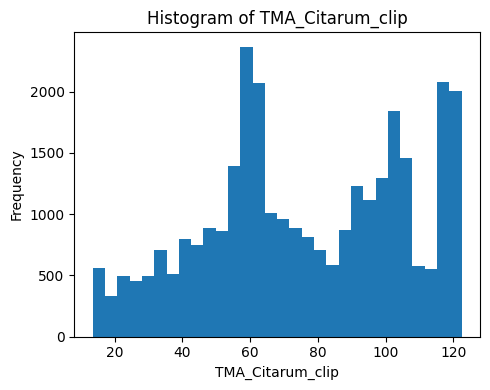

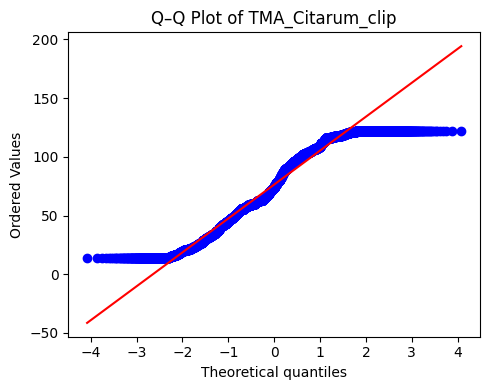

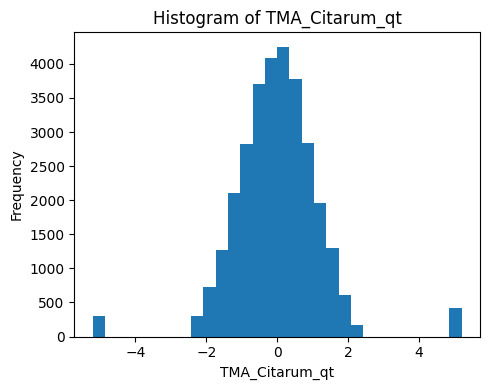

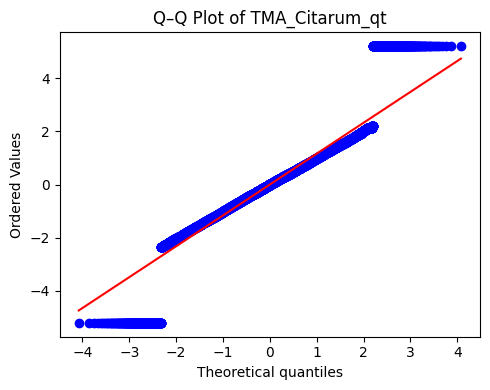

In [23]:
# 2. Pilih variants khusus untuk TMA_Cipalasari
var = 'TMA_Citarum'
variants = [
    f'{var}_pt',
    # f'{var}_log',
    f'{var}_norm',
    f'{var}_clip',
    f'{var}_qt'
]

# 3. Hitung skewness, kurtosis, dan normality test untuk tiap variant
results = []
for col in variants:
    data = df_copy[col].dropna()
    skew = data.skew()
    kurt = data.kurtosis()
    if len(data) <= 5000:
        _, p = stats.shapiro(data)
        test = 'Shapiro–Wilk'
    else:
        _, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    results.append({
        'variant': col,
        'skewness': skew,
        'kurtosis': kurt,
        'test': test,
        'p_value': p
    })

results_df = pd.DataFrame(results)
print(results_df)

# 4. Visualisasi histogram dan Q–Q plot
for col in variants:
    data = df_copy[col].dropna()

    plt.figure(figsize=(5,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col); plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5,4))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f'Q–Q Plot of {col}')
    plt.tight_layout()
    plt.show()


          variant  skewness  kurtosis           test  p_value
0    TMA_Kolam_pt -0.085123 -1.654087  D’Agostino K²      0.0
1  TMA_Kolam_norm -0.076636  5.672046  D’Agostino K²      0.0
2  TMA_Kolam_clip -0.086354 -1.656178  D’Agostino K²      0.0
3    TMA_Kolam_qt -0.076636  5.672046  D’Agostino K²      0.0


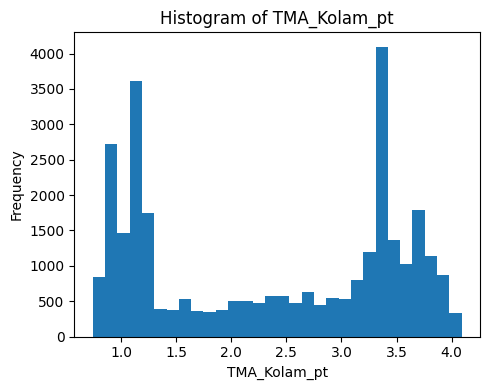

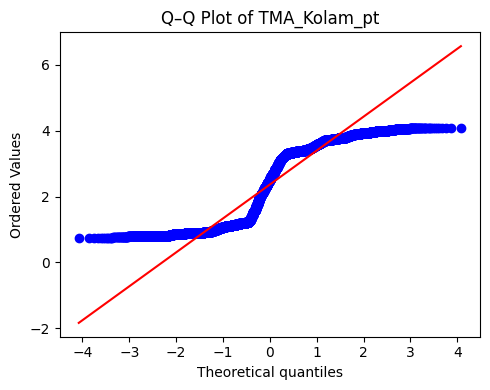

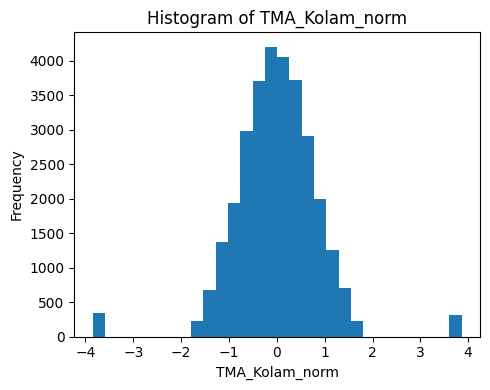

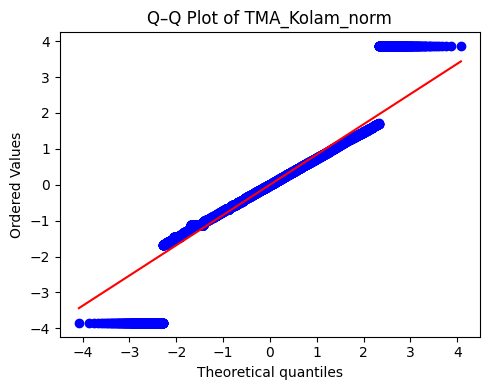

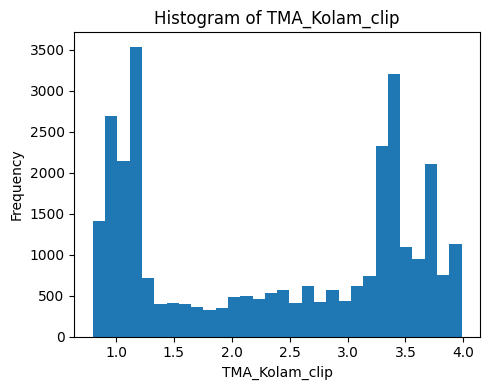

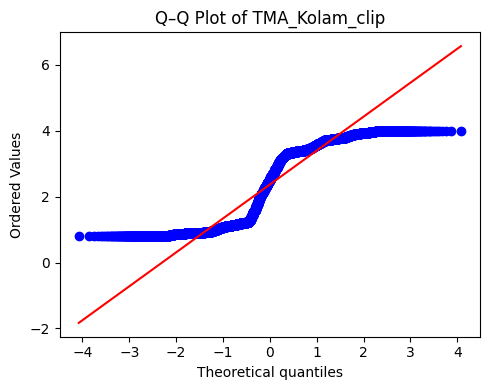

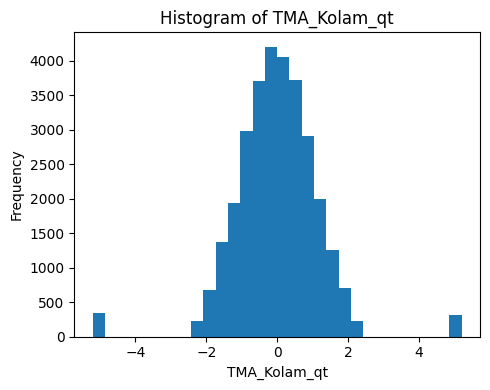

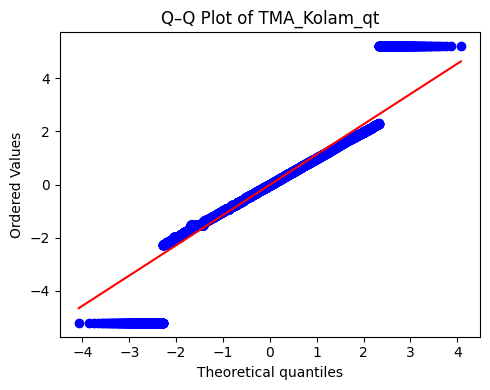

In [24]:
# 2. Pilih variants khusus untuk TMA_Cipalasari
var = 'TMA_Kolam'
variants = [
    f'{var}_pt',
    # f'{var}_log',
    f'{var}_norm',
    f'{var}_clip',
    f'{var}_qt'
]

# 3. Hitung skewness, kurtosis, dan normality test untuk tiap variant
results = []
for col in variants:
    data = df_copy[col].dropna()
    skew = data.skew()
    kurt = data.kurtosis()
    if len(data) <= 5000:
        _, p = stats.shapiro(data)
        test = 'Shapiro–Wilk'
    else:
        _, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    results.append({
        'variant': col,
        'skewness': skew,
        'kurtosis': kurt,
        'test': test,
        'p_value': p
    })

results_df = pd.DataFrame(results)
print(results_df)

# 4. Visualisasi histogram dan Q–Q plot
for col in variants:
    data = df_copy[col].dropna()
    
    plt.figure(figsize=(5,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col); plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5,4))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f'Q–Q Plot of {col}')
    plt.tight_layout()
    plt.show()


In [25]:
df_copy.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,Debit_Cipalasari_log,Debit_Cipalasari_clip,...,bojongsoang_clip,rain_flag_bojong,bojongsoang_qt,bojongsoang_norm,dayeuhkolot_log,dayeuhkolot_clip,rain_flag_day,dayeuhkolot_qt,dayeuhkolot_norm,pump
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,0.0,0.0,0.382560,0.382560,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,0.0,0.0,0.385541,0.385541,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,0.0,0.0,0.391598,0.391598,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,0.0,0.0,0.397618,0.397618,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,0.0,0.0,0.403602,0.403602,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2


            variant  skewness  kurtosis           test        p_value
0   dayeuhkolot_log  2.090384  2.687338  D’Agostino K²   0.000000e+00
1  dayeuhkolot_norm -0.084631 -0.481393  D’Agostino K²  1.379437e-123
2  dayeuhkolot_clip  2.090384  2.687338  D’Agostino K²   0.000000e+00
3    dayeuhkolot_qt -0.084631 -0.481393  D’Agostino K²  1.379437e-123


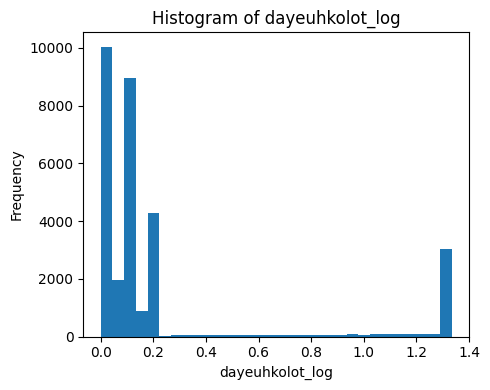

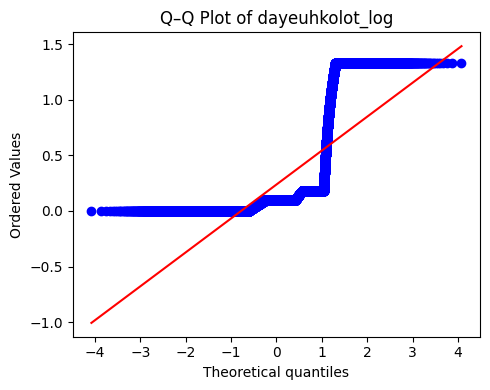

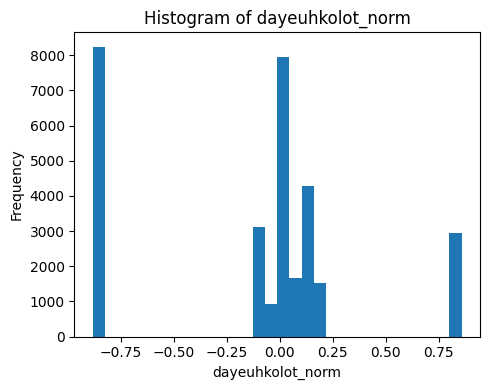

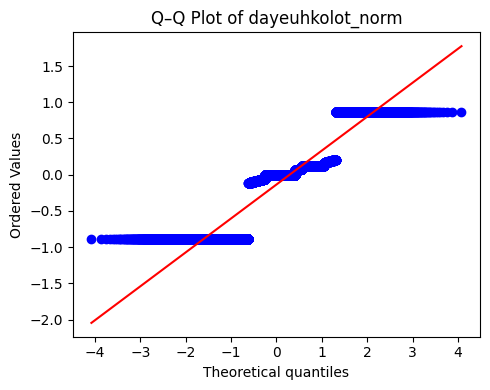

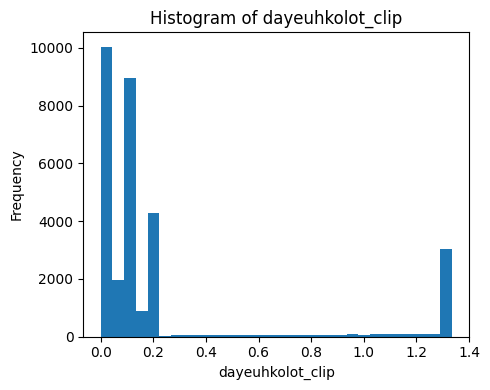

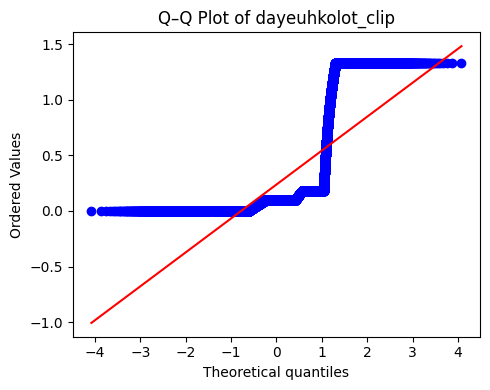

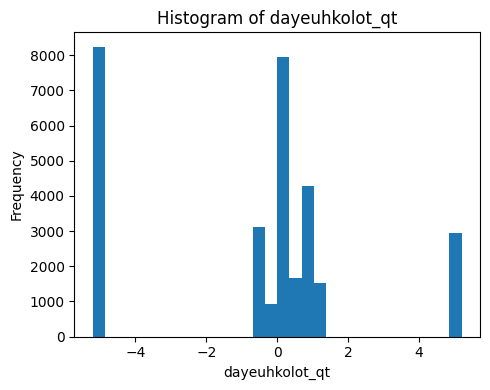

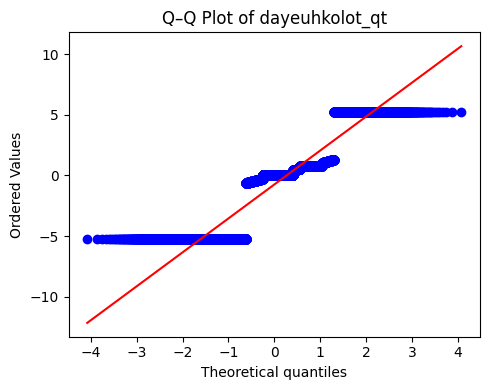

In [26]:
# 2. Pilih variants khusus untuk TMA_Cipalasari
var = 'dayeuhkolot'
variants = [
    # f'{var}_pt',
    f'{var}_log',
    f'{var}_norm',
    f'{var}_clip',
    f'{var}_qt'
]

# 3. Hitung skewness, kurtosis, dan normality test untuk tiap variant
results = []
for col in variants:
    data = df_copy[col].dropna()
    skew = data.skew()
    kurt = data.kurtosis()
    if len(data) <= 5000:
        _, p = stats.shapiro(data)
        test = 'Shapiro–Wilk'
    else:
        _, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    results.append({
        'variant': col,
        'skewness': skew,
        'kurtosis': kurt,
        'test': test,
        'p_value': p
    })

results_df = pd.DataFrame(results)
print(results_df)

# 4. Visualisasi histogram dan Q–Q plot
for col in variants:
    data = df_copy[col].dropna()

    plt.figure(figsize=(5,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col); plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5,4))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f'Q–Q Plot of {col}')
    plt.tight_layout()
    plt.show()


            variant  skewness  kurtosis           test        p_value
0   bojongsoang_log  2.061792  2.627861  D’Agostino K²   0.000000e+00
1  bojongsoang_norm -0.081949 -0.477180  D’Agostino K²  2.186699e-120
2  bojongsoang_clip  2.061792  2.627861  D’Agostino K²   0.000000e+00
3    bojongsoang_qt -0.081949 -0.477180  D’Agostino K²  2.186699e-120


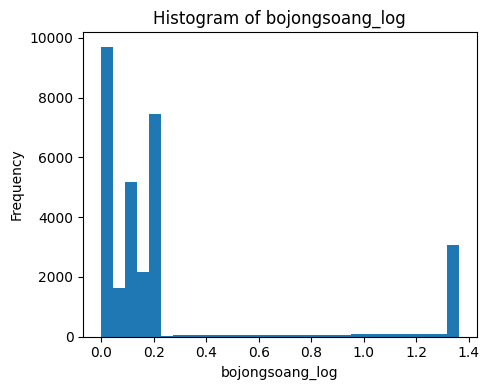

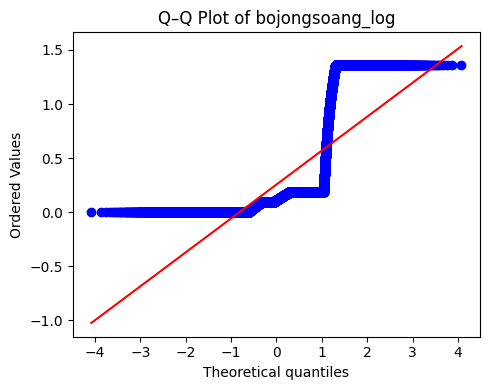

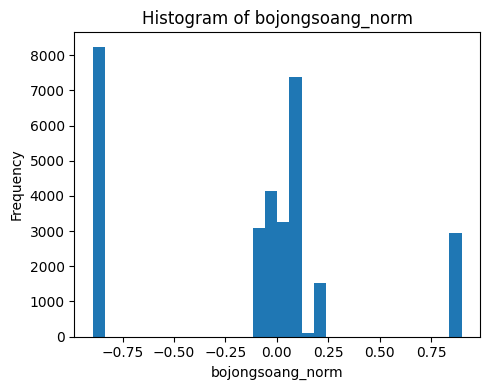

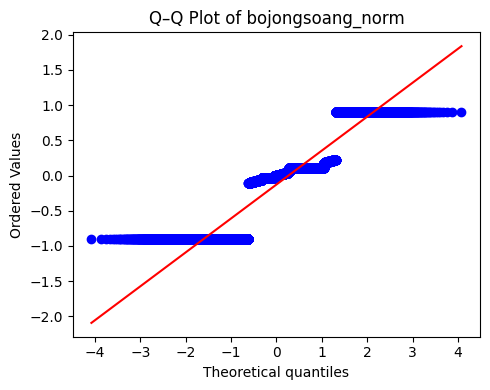

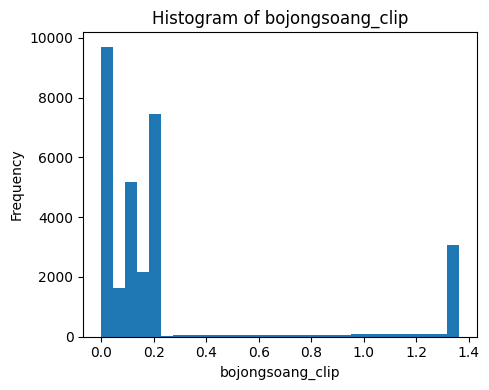

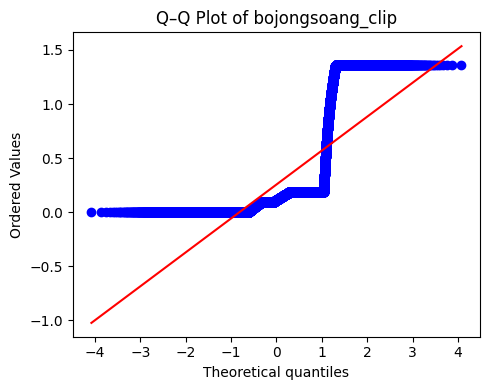

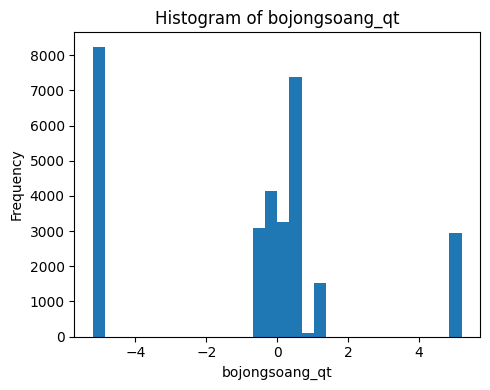

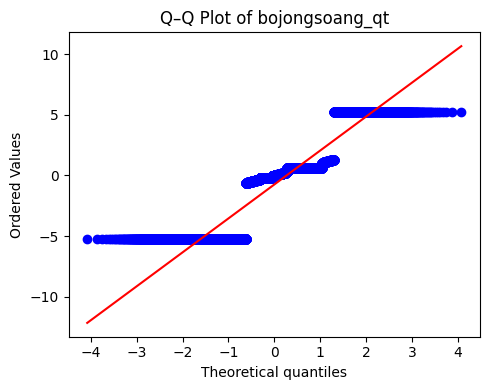

In [27]:
# 2. Pilih variants khusus untuk TMA_Cipalasari
var = 'bojongsoang'
variants = [
    # f'{var}_pt',
    f'{var}_log',
    f'{var}_norm',
    f'{var}_clip',
    f'{var}_qt'
]

# 3. Hitung skewness, kurtosis, dan normality test untuk tiap variant
results = []
for col in variants:
    data = df_copy[col].dropna()
    skew = data.skew()
    kurt = data.kurtosis()
    if len(data) <= 5000:
        _, p = stats.shapiro(data)
        test = 'Shapiro–Wilk'
    else:
        _, p = stats.normaltest(data)
        test = 'D’Agostino K²'
    results.append({
        'variant': col,
        'skewness': skew,
        'kurtosis': kurt,
        'test': test,
        'p_value': p
    })

results_df = pd.DataFrame(results)
print(results_df)

# 4. Visualisasi histogram dan Q–Q plot
for col in variants:
    data = df_copy[col].dropna()

    plt.figure(figsize=(5,4))
    plt.hist(data, bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col); plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5,4))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f'Q–Q Plot of {col}')
    plt.tight_layout()
    plt.show()


In [28]:
df_copy.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,Debit_Cipalasari_log,Debit_Cipalasari_clip,...,bojongsoang_clip,rain_flag_bojong,bojongsoang_qt,bojongsoang_norm,dayeuhkolot_log,dayeuhkolot_clip,rain_flag_day,dayeuhkolot_qt,dayeuhkolot_norm,pump
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,0.0,0.0,0.382560,0.382560,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,0.0,0.0,0.385541,0.385541,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,0.0,0.0,0.391598,0.391598,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,0.0,0.0,0.397618,0.397618,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,0.0,0.0,0.403602,0.403602,...,0.0,0,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2


In [32]:
df_copy.to_csv('processed_data.csv', index=False)

In [ ]:
# def recommend_pump(tma_cm):
#     if tma_cm < 3.2:
#         return 0  # Aman
#     elif tma_cm <= 9.6:
#         return 1  # Siaga1
#     elif tma_cm <= 14.4:
#         return 2  # Siaga2
#     else:
#         return 3  # Siaga3+

# df_copy['pump_recommendation'] = df_copy['TMA_Kolam'].apply(recommend_pump)

# # 4. Gunakan kolom status_banjir yang sudah ada di dataset sebagai target
# #    (jangan overwrite dengan pump_recommendation)
# #    Pastikan df['status_banjir'] sudah tersedia: 0=aman,1=siaga1,2=siaga2,3=siaga3

# # 5. Definisikan fitur dan target
# feature_cols = [
#     'Debit_Cipalasari_norm',
#     'Debit_Hilir_norm',
#     'Debit_Hulu_norm',
#     'TMA_Cipalasari_norm',
#     'TMA_Citarum_norm',
#     'TMA_Kolam_norm',
# ]
# X = df_copy[feature_cols]
# y = df_copy['status_banjir'] =  df_copy['pump_recommendation']

# # 6. Split data
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.3, random_state=42, stratify=y
# )

# # 7. Inisialisasi model-model yang akan dibandingkan
# models = {
#     'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
#     'DecisionTree': DecisionTreeClassifier(random_state=42),
#     'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
#     'LogisticRegression': LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42),
#     'SupportVectorMachine': SVC(probability=True, random_state=42)

# }

# # 8. Latih, prediksi, dan evaluasi tiap model
# results = []
# for name, model in models.items():
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     results.append({
#         'Model': name,
#         'Accuracy': accuracy_score(y_test, y_pred),
#         'F1 (weighted)': f1_score(y_test, y_pred, average='weighted'),
#         'MAE': mean_absolute_error(y_test, y_pred),
#         'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
#     })

# results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
# print(results_df)





d:\1. TELKOM UNIVERSITY\1. COOLYEAH\TA\MACHINE LEARNING\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:51:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                  Model  Accuracy  F1 (weighted)       MAE      RMSE
1          DecisionTree  0.999891       0.999891  0.000109  0.010428
2          RandomForest  0.999783       0.999783  0.000217  0.014747
0               XGBoost  0.996520       0.996521  0.003480  0.058990
3    LogisticRegression  0.981405       0.981454  0.018595  0.136364
4  SupportVectorMachine  0.972706       0.972769  0.027294  0.165210


In [45]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline


# ==============================================================================
# TAHAP 1: PERSIAPAN DATA
# ==============================================================================

# Asumsikan Anda memuat data asli (belum dinormalisasi) ke dalam DataFrame 'df'
# Contoh: df = pd.read_csv('data_banjir_asli.csv')
# Pastikan 'df' Anda memiliki kolom-kolom berikut dengan nilai aslinya:
# 'Debit_Cipalasari', 'Debit_Hilir', 'Debit_Hulu', 
# 'TMA_Cipalasari', 'TMA_Citarum', 'TMA_Kolam'




# ---------------------------------------------------------------

# 1. Buat kolom target (label) berdasarkan data asli TMA Kolam
def recommend_pump(tma_cm):
    if tma_cm < 3.2:
        return 0  # Aman
    elif tma_cm <= 9.6:
        return 1  # Siaga1
    elif tma_cm <= 14.4:
        return 2  # Siaga2
    else:
        return 3  # Siaga3
    
    # Terapkan fungsi ke kolom TMA_Kolam yang asli (bukan yang _norm)
df_copy['pump_recommendation'] = df_copy['TMA_Kolam'].apply(recommend_pump)

# 2. Definisikan fitur dan target MENGGUNAKAN DATA ASLI
# <-- PERUBAHAN KRUSIAL 1: Gunakan nama kolom asli, bukan yang '_norm'
feature_cols = [
    'Debit_Cipalasari',
    'Debit_Hilir',
    'Debit_Hulu',
    'TMA_Cipalasari',
    'TMA_Citarum',
    'TMA_Kolam',
]

X = df_copy[feature_cols]
y = df_copy['status_banjir'] =  df_copy['pump_recommendation']

# 3. Split data (data fitur yang di-split masih dalam bentuk data asli)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ==============================================================================
# TAHAP 2: PEMBUATAN PIPELINE DAN PELATIHAN
# ==============================================================================

# 4. Bangun Pipeline untuk setiap model
# <-- PERUBAHAN KRUSIAL 2: Setiap 'model' kini adalah sebuah 'Pipeline'
#    Pipeline ini terdiri dari 2 langkah: 'scaler' (normalisasi) dan 'classifier' (model ML)
pipelines = {
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()), 
        ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42))
    ]),
    'SupportVectorMachine': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', SVC(probability=True, random_state=42))
    ])
}

# 5. Latih, prediksi, dan evaluasi setiap PIPELINE
results = []
for name, pipeline in pipelines.items():
    print(f"Melatih model {name}...")
    
    # Melatih pipeline (otomatis melakukan scaling pada X_train lalu melatih classifier)
    pipeline.fit(X_train, y_train)
    
    # Melakukan prediksi (otomatis melakukan scaling pada X_test lalu prediksi)
    y_pred = pipeline.predict(X_test)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 (weighted)': f1_score(y_test, y_pred, average='weighted'),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    })

print("\n--- HASIL EVALUASI MODEL ---")
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(results_df)


Melatih model XGBoost...


d:\1. TELKOM UNIVERSITY\1. COOLYEAH\TA\MACHINE LEARNING\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:31:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Melatih model DecisionTree...
Melatih model RandomForest...
Melatih model LogisticRegression...
Melatih model SupportVectorMachine...

--- HASIL EVALUASI MODEL ---
                  Model  Accuracy  F1 (weighted)       MAE      RMSE
1          DecisionTree  0.999891       0.999891  0.000109  0.010428
2          RandomForest  0.999674       0.999674  0.000326  0.018062
0               XGBoost  0.998913       0.998912  0.001087  0.032976
3    LogisticRegression  0.993584       0.993576  0.006416  0.080099
4  SupportVectorMachine  0.985211       0.985194  0.014898  0.122944


In [51]:
# ==============================================================================
# TAHAP 3: PERCOBAAN PREDIKSI DENGAN DATA ASLI
# ==============================================================================
# <-- PERUBAHAN KRUSIAL 3: Sekarang Anda bisa input data asli untuk prediksi!

print("\n" + "="*40)
print("==          PERCOBAAN PREDIKSI DENGAN DATA ASLI         ==")
print("="*40 + "\n")

# 1. Pilih pipeline terbaik dari hasil evaluasi
best_model_name = results_df.iloc[0]['Model']
best_pipeline = pipelines[best_model_name]
print(f"✅ Model terbaik yang digunakan: **{best_model_name}**\n")

# 2. Buat data baru dengan nilai-nilai asli (bukan yang sudah dinormalisasi)
data_baru_asli = {
    'Debit_Cipalasari': [5],
    'Debit_Hilir': [8],
    'Debit_Hulu': [6],
    'TMA_Cipalasari': [2],
    'TMA_Citarum': [20],
    'TMA_Kolam': [15]  # TMA Kolam 15 cm (seharusnya masuk kategori Siaga 3)
}

# Konversi ke DataFrame dengan urutan kolom yang sama persis
data_untuk_prediksi = pd.DataFrame(data_baru_asli, columns=feature_cols)

# 3. Lakukan prediksi menggunakan pipeline terbaik
# Pipeline akan otomatis menormalisasi data ini sebelum membuat prediksi
prediksi_kode = best_pipeline.predict(data_untuk_prediksi)[0]

# 4. Tampilkan hasil yang mudah dibaca
status_mapping = {0: 'Aman', 1: 'Siaga 1', 2: 'Siaga 2', 3: 'Siaga 3'}
prediksi_label = status_mapping[prediksi_kode]

print("--- 💧 Skenario Prediksi ---")
print("Data Input (Nilai Asli):")
print(data_untuk_prediksi.to_string(index=False))
print("-" * 25)
print(f"Hasil Prediksi  : **{prediksi_label}** (Kode: {prediksi_kode})")
print("\n")


==          PERCOBAAN PREDIKSI DENGAN DATA ASLI         ==

✅ Model terbaik yang digunakan: **DecisionTree**

--- 💧 Skenario Prediksi ---
Data Input (Nilai Asli):
 Debit_Cipalasari  Debit_Hilir  Debit_Hulu  TMA_Cipalasari  TMA_Citarum  TMA_Kolam
                5            8           6               2           20         15
-------------------------
Hasil Prediksi  : **Siaga 3** (Kode: 3)




In [30]:
df_copy.head()

,Debit_Cipalasari,Debit_Hilir,Debit_Hulu,TMA_Cipalasari,TMA_Citarum,TMA_Kolam,bojongsoang,dayeuhkolot,Debit_Cipalasari_log,Debit_Cipalasari_clip,...,bojongsoang_qt,bojongsoang_norm,dayeuhkolot_log,dayeuhkolot_clip,rain_flag_day,dayeuhkolot_qt,dayeuhkolot_norm,pump,pump_recommendation,status_banjir
0,0.466032,2.389919,1.819317,0.634561,6.569780,12.875024,0.0,0.0,0.382560,0.382560,...,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,2,2
1,0.470409,2.398388,1.836405,0.629908,6.559635,12.874414,0.0,0.0,0.385541,0.385541,...,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,2,2
2,0.479342,2.415673,1.871278,0.620411,6.538929,12.873169,0.0,0.0,0.391598,0.391598,...,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,2,2
3,0.488275,2.432957,1.906150,0.610914,6.518223,12.871923,0.0,0.0,0.397618,0.397618,...,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,2,2
4,0.497208,2.450241,1.941023,0.601418,6.497517,12.870678,0.0,0.0,0.403602,0.403602,...,-5.199338,-0.89437,0.0,0.0,0,-5.199338,-0.881862,2,2,2
